# ASVspoof2019 LA Deepfake Audio Detection (BiLSTM + Attention)

This notebook implements the strict end-to-end pipeline:
load → light VAD → crop/pad 4s → MFCC+delta+delta2 → CMVN → fixed (T,120) → BiLSTM+Attention → logits → metrics → tDCF.

Runtime policy:

**CPU Validation Phase (Cells 1–23)**
1. Set `RUNTIME_MODE = 'CPU'` in Cell 4.
2. Run Cells 1–23 sequentially.
   - Cell 18 (overfit): pre-warms cache for 50 samples; uses `random_crop=True`.
   - Cell 19 (dry run): pre-warms cache for 256 samples; evaluates on 512-sample dev subset.
   - Cell 21 (dev tDCF): keep `RUN_FULL_DEV=False` during CPU phase.
3. Cell 23 raises `RuntimeError` intentionally — stop here.

**CUDA Training Phase (after full kernel restart)**
4. Set `RUNTIME_MODE = 'CUDA'` in Cell 4.
5. Re-run Cells 2–15 (initialisation only — do NOT run 16–23 again).
6. Run Cell 25: parallel pre-warms all ~25k training files (first run ~25–40 min, instant after).
7. Run Cell 26: full training (up to 25 epochs, early stopping on val EER). Checkpoint saved from `model._orig_mod` to avoid torch.compile key prefix issues.
8. Cell 26 — diagnostic runs automatically before training loop.
9. Run Cell 27A: loads checkpoint, parallel pre-warms eval set, runs inference, writes scores, computes final min-tDCF.

**Official full-dev tDCF/scoring**
10. After Cell 26, run Cell 27B


In [1]:
# Cell 2

import os
import csv
import time
import random
import sys
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score,
    f1_score, precision_score, recall_score,
    confusion_matrix as sk_confusion_matrix,
)


In [2]:
# Cell 3

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
# FIX: benchmark starts False here; Cell 4 sets it True for CUDA mode.
# Do NOT change this line — Cell 4 overrides it correctly per runtime mode.
torch.backends.cudnn.benchmark = False

ROOT = Path('.').resolve()
DATA_ROOT = ROOT / 'ASVspoof2019_LA'
TRAIN_AUDIO_DIR = DATA_ROOT / 'ASVspoof2019_LA_train' / 'flac'
DEV_AUDIO_DIR   = DATA_ROOT / 'ASVspoof2019_LA_dev'   / 'flac'
EVAL_AUDIO_DIR  = DATA_ROOT / 'ASVspoof2019_LA_eval'  / 'flac'

TRAIN_PROTOCOL = DATA_ROOT / 'ASVspoof2019_LA_cm_protocols' / 'ASVspoof2019.LA.cm.train.trn.txt'
DEV_PROTOCOL   = DATA_ROOT / 'ASVspoof2019_LA_cm_protocols' / 'ASVspoof2019.LA.cm.dev.trl.txt'
EVAL_PROTOCOL  = DATA_ROOT / 'ASVspoof2019_LA_cm_protocols' / 'ASVspoof2019.LA.cm.eval.trl.txt'

ASV_DEV_SCORES  = DATA_ROOT / 'ASVspoof2019_LA_asv_scores' / 'ASVspoof2019.LA.asv.dev.gi.trl.scores.txt'
ASV_EVAL_SCORES = DATA_ROOT / 'ASVspoof2019_LA_asv_scores' / 'ASVspoof2019.LA.asv.eval.gi.trl.scores.txt'

ARTIFACT_DIR = ROOT / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
FEATURE_CACHE_DIR = ARTIFACT_DIR / 'feature_cache'
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
DIRECTION_WARNING_LOG = ARTIFACT_DIR / 'direction_warnings.log'

# Stable EXPERIMENT_ID across kernel re-runs in the same session.
if 'EXPERIMENT_ID' not in globals():
    EXPERIMENT_ID = time.strftime('exp_%Y%m%d_%H%M%S')
    # Only wipe the direction-warning log for a genuinely new experiment.
    DIRECTION_WARNING_LOG.write_text('', encoding='utf-8')
    print('New experiment started:', EXPERIMENT_ID)
else:
    print('Resuming existing experiment:', EXPERIMENT_ID)

CSV_LOG         = ARTIFACT_DIR / f'{EXPERIMENT_ID}_metrics.csv'
BEST_MODEL_PATH = ARTIFACT_DIR / f'{EXPERIMENT_ID}_best_model.pt'
DEV_SCORE_PATH  = ARTIFACT_DIR / f'{EXPERIMENT_ID}_dev_scores.txt'
EVAL_SCORE_PATH = ARTIFACT_DIR / f'{EXPERIMENT_ID}_eval_scores.txt'

SR              = 16000
TARGET_SEC      = 4.0
TARGET_SAMPLES  = int(SR * TARGET_SEC)
N_MFCC          = 40
N_FFT           = 512
WIN_LENGTH      = 400
HOP_LENGTH      = 160
VAD_THR_FACTOR  = 0.5
FEAT_DIM        = 120
FIXED_T         = 400
N_MULTICROP     = 5
BATCH_SIZE      = 128
CPU_NUM_WORKERS = 0
CPU_PIN_MEMORY  = False
CUDA_NUM_WORKERS = 2
CUDA_PIN_MEMORY  = True
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
WARMUP_EPOCHS   = 3
MAX_EPOCHS      = 25
CLIP_NORM       = 1.0
DIRECTION_CHECK_WARMUP = 3
EARLY_STOP_PATIENCE    = 5

# FIX: cap direction warning log at 500 lines to prevent unbounded growth.
MAX_DIRECTION_WARNING_LINES = 500

print('Experiment ID:', EXPERIMENT_ID)
print('Artifacts:', ARTIFACT_DIR)
print('Feature cache:', FEATURE_CACHE_DIR)


New experiment started: exp_20260429_040549
Experiment ID: exp_20260429_040549
Artifacts: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts
Feature cache: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\feature_cache


In [3]:
# Cell 4

import torch
import os

RUNTIME_MODE = 'CUDA'   # Switch to 'CPU' for validation phase
VALID_MODES = {'CPU', 'CUDA'}
assert RUNTIME_MODE in VALID_MODES, f'Invalid RUNTIME_MODE: {RUNTIME_MODE}'

torch.set_num_threads(os.cpu_count() or 4)
try:
    torch.set_num_interop_threads(max(1, (os.cpu_count() or 4) // 2))
except RuntimeError:
    pass

print(f'PyTorch using {torch.get_num_threads()} intra-op threads.')

cpu_num_workers  = int(globals().get('CPU_NUM_WORKERS', 0))
cpu_pin_memory   = False
cuda_num_workers = int(globals().get('CUDA_NUM_WORKERS', 2))
cuda_pin_memory  = bool(globals().get('CUDA_PIN_MEMORY', True))

if RUNTIME_MODE == 'CPU':
    os.environ['CUDA_VISIBLE_DEVICES'] = ''
    DEVICE = torch.device('cpu')
    DATALOADER_NUM_WORKERS = cpu_num_workers
    DATALOADER_PIN_MEMORY  = cpu_pin_memory
else:
    assert torch.cuda.is_available(), 'RUNTIME_MODE is CUDA but CUDA is not available.'
    DEVICE = torch.device('cuda')
    DATALOADER_NUM_WORKERS = cuda_num_workers
    DATALOADER_PIN_MEMORY  = cuda_pin_memory
    # FIX: benchmark set True here (Cell 3 set it False as a safe default).
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = True

if RUNTIME_MODE == 'CPU':
    assert str(DEVICE) == 'cpu'
else:
    assert DEVICE.type == 'cuda'

print('Active runtime mode:', RUNTIME_MODE)
print('Active device:', DEVICE)
print('DataLoader workers/pin_memory:', DATALOADER_NUM_WORKERS, DATALOADER_PIN_MEMORY)


PyTorch using 12 intra-op threads.
Active runtime mode: CUDA
Active device: cuda
DataLoader workers/pin_memory: 2 True


In [4]:
# Cell 5

def parse_cm_protocol(path: Path) -> List[Dict]:
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            speaker_id = parts[0]
            utt_id = parts[1]
            attack = parts[3] if len(parts) > 4 else '-'
            label_str = parts[-1]
            if label_str not in {'bonafide', 'spoof'}:
                raise ValueError(f'Unexpected label in protocol: {label_str!r} (line: {line.strip()!r})')
            label = 1 if label_str == 'spoof' else 0
            records.append({
                'speaker_id': speaker_id,
                'utt_id': utt_id,
                'attack': attack,
                'label_str': label_str,
                'label': label
            })
    return records

def parse_asv_scores(path: Path) -> Dict[str, np.ndarray]:
    """
    FIX: malformed or short lines now raise a descriptive ValueError instead
    of being silently skipped, which could cause tDCF alignment errors.
    """
    target, nontarget, spoof = [], [], []
    with open(path, 'r', encoding='utf-8') as f:
        for lineno, line in enumerate(f, 1):
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) == 3:
                trial_type = parts[1]
                score_str  = parts[2]
            elif len(parts) >= 4:
                trial_type = parts[-2]
                score_str  = parts[-1]
            else:
                raise ValueError(
                    f'parse_asv_scores: unexpected format at line {lineno}: {line.strip()!r}'
                )
            try:
                score = float(score_str)
            except ValueError:
                raise ValueError(
                    f'parse_asv_scores: cannot parse score {score_str!r} at line {lineno}'
                )
            if trial_type == 'target':
                target.append(score)
            elif trial_type == 'nontarget':
                nontarget.append(score)
            elif trial_type == 'spoof':
                spoof.append(score)
            # unknown trial_type silently ignored — consistent with original intent

    return {
        'target':    np.asarray(target,    dtype=np.float64),
        'nontarget': np.asarray(nontarget, dtype=np.float64),
        'spoof':     np.asarray(spoof,     dtype=np.float64),
    }

train_records = parse_cm_protocol(TRAIN_PROTOCOL)
dev_records   = parse_cm_protocol(DEV_PROTOCOL)
eval_records  = parse_cm_protocol(EVAL_PROTOCOL)
train_bonafide_count = sum(1 for r in train_records if r['label'] == 0)
train_spoof_count    = sum(1 for r in train_records if r['label'] == 1)
assert train_spoof_count > 0, 'Training protocol has no spoof samples; cannot compute pos_weight.'
POS_WEIGHT_VALUE = train_bonafide_count / train_spoof_count
print('Training bonafide count:', train_bonafide_count)
print('Training spoof count:',    train_spoof_count)
print('Computed POS_WEIGHT_VALUE:', POS_WEIGHT_VALUE)
print('Protocol sizes:', len(train_records), len(dev_records), len(eval_records))


Training bonafide count: 2580
Training spoof count: 22800
Computed POS_WEIGHT_VALUE: 0.11315789473684211
Protocol sizes: 25380 24844 71237


In [5]:
# Cell 6

print('Training label summary:')
print('  bonafide samples:', train_bonafide_count)
print('  spoof samples   :', train_spoof_count)
print('  pos_weight      :', POS_WEIGHT_VALUE)
assert train_bonafide_count > 0
assert train_spoof_count    > 0
assert POS_WEIGHT_VALUE     > 0


Training label summary:
  bonafide samples: 2580
  spoof samples   : 22800
  pos_weight      : 0.11315789473684211


In [6]:
# Cell 7

def load_audio(path: Path, sr: int = SR) -> np.ndarray:
    y, _ = librosa.load(path.as_posix(), sr=sr, mono=True)
    if y.size == 0:
        raise ValueError(f'Empty audio file: {path}')
    return y.astype(np.float32)

def light_vad(
    y: np.ndarray,
    frame_length: int   = WIN_LENGTH,
    hop_length:   int   = HOP_LENGTH,
    vad_thr_factor: float = VAD_THR_FACTOR,
) -> np.ndarray:
    rms    = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length, center=True)[0]
    thr    = max(np.median(rms) * vad_thr_factor, 1e-5)
    active = np.where(rms > thr)[0]
    if active.size == 0:
        return y
    start_frame, end_frame = int(active[0]), int(active[-1])
    start_sample = max(0, start_frame * hop_length)
    end_sample   = min(len(y), end_frame * hop_length + frame_length)
    voiced = y[start_sample:end_sample]
    return voiced if voiced.size > 0 else y

print('Cell 7 defines: load_audio, light_vad')


Cell 7 defines: load_audio, light_vad


In [7]:
# Cell 8

def extract_feature_sequence(y: np.ndarray, sr: int = SR) -> np.ndarray:
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
    )
    d1   = librosa.feature.delta(mfcc, order=1)
    d2   = librosa.feature.delta(mfcc, order=2)
    feat = np.concatenate([mfcc, d1, d2], axis=0).T  # (frames, 120)

    mean = feat.mean(axis=0, keepdims=True)
    std  = feat.std(axis=0,  keepdims=True) + 1e-8
    feat = (feat - mean) / std

    feat = feat.astype(np.float32)
    assert feat.shape[1] == FEAT_DIM, f'Feature shape guard failed: {feat.shape}'
    assert np.isfinite(feat).all(),   'NaN/Inf guard failed in feature matrix.'
    return feat


def crop_or_pad_feature_sequence(
    feat: np.ndarray,
    fixed_t: int = FIXED_T,
) -> np.ndarray:
    """Single random crop + zero-pad to (fixed_t, FEAT_DIM). Training only."""
    T = feat.shape[0]
    if T > fixed_t:
        start = int(np.random.randint(0, T - fixed_t + 1))
        feat  = feat[start:start + fixed_t, :]
    elif T < fixed_t:
        pad  = np.zeros((fixed_t - T, FEAT_DIM), dtype=np.float32)
        feat = np.concatenate([feat, pad], axis=0)
    assert feat.shape == (fixed_t, FEAT_DIM), f'Shape guard: {feat.shape}'
    assert np.isfinite(feat).all(), 'NaN/Inf in cropped feature.'
    return feat


def get_multicrop_feature_sequence(
    feat: np.ndarray,
    fixed_t: int = FIXED_T,
    n_crops: int = N_MULTICROP,
) -> np.ndarray:
    """N evenly-spaced crops → (N, fixed_t, FEAT_DIM). Val/test only."""
    assert n_crops >= 1, f'n_crops must be >= 1, got {n_crops}'
    T = feat.shape[0]
    if T <= fixed_t:
        pad    = np.zeros((fixed_t - T, FEAT_DIM), dtype=np.float32)
        padded = np.concatenate([feat, pad], axis=0)
        crops  = np.repeat(padded[np.newaxis, ...], n_crops, axis=0)
    else:
        starts = np.linspace(0, T - fixed_t, n_crops, dtype=int)
        crops  = np.stack([feat[s:s + fixed_t] for s in starts])

    assert crops.shape == (n_crops, fixed_t, FEAT_DIM), f'Shape guard: {crops.shape}'
    assert np.isfinite(crops).all(), 'NaN/Inf in multicrop feature.'
    return crops.astype(np.float32)


print('Cell 8 defines: extract_feature_sequence, crop_or_pad_feature_sequence, get_multicrop_feature_sequence')


Cell 8 defines: extract_feature_sequence, crop_or_pad_feature_sequence, get_multicrop_feature_sequence


In [8]:
# Cell 9

FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print('Feature cache directory:', FEATURE_CACHE_DIR)


Feature cache directory: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\feature_cache


In [9]:
# Cell 10

class ASVspoofCMFeatureDataset(Dataset):
    def __init__(self, records: List[Dict], audio_dir: Path, random_crop: bool = False):
        self.records     = records
        self.audio_dir   = audio_dir
        self.random_crop = random_crop
        # FIX: use str keys instead of Path objects — str hashing is faster.
        self._mem_cache: dict = {}

    def __len__(self):
        return len(self.records)

    def _cache_path(self, wav_path: Path) -> Path:
        cache_name = (
            f"{self.audio_dir.parent.name}_{wav_path.stem}"
            f"_sr{SR}_mfcc{N_MFCC}_nfft{N_FFT}"
            f"_flen{WIN_LENGTH}_hlen{HOP_LENGTH}"
            f"_vad_thr{str(VAD_THR_FACTOR).replace('.','p')}.npy"
        )
        return FEATURE_CACHE_DIR / cache_name

    def _load_or_build_feature_cache(self, wav_path: Path) -> np.ndarray:
        cache_path = self._cache_path(wav_path)
        # FIX: use str key for faster hashing
        cache_key  = str(cache_path)

        if cache_key in self._mem_cache:
            return self._mem_cache[cache_key]

        if cache_path.exists():
            feat = np.load(cache_path, allow_pickle=False)
            self._mem_cache[cache_key] = feat
            return feat

        y    = load_audio(wav_path, sr=SR)
        y    = light_vad(y, vad_thr_factor=VAD_THR_FACTOR)
        feat = extract_feature_sequence(y, sr=SR)
        np.save(cache_path, feat.astype(np.float32))
        self._mem_cache[cache_key] = feat
        return feat

    def __getitem__(self, idx: int):
        rec      = self.records[idx]
        wav_path = self.audio_dir / f"{rec['utt_id']}.flac"
        feat     = self._load_or_build_feature_cache(wav_path)

        if self.random_crop:
            feat = crop_or_pad_feature_sequence(feat, FIXED_T)
            x    = torch.from_numpy(feat)
        else:
            crops = get_multicrop_feature_sequence(feat, FIXED_T, N_MULTICROP)
            x     = torch.from_numpy(crops)

        y_lbl = torch.tensor(float(rec['label']), dtype=torch.float32)
        return x, y_lbl, rec['utt_id'], rec['label_str']


def _worker_init_fn(worker_id: int) -> None:
    """Seed numpy, torch, AND python random per worker for full reproducibility."""
    # FIX: also seed Python's random module (was missing)
    random.seed(SEED + worker_id)
    np.random.seed(SEED + worker_id)
    torch.manual_seed(SEED + worker_id)


def make_loader(dataset: Dataset, batch_size: int, shuffle: bool, runtime_mode: str) -> DataLoader:
    # FIX: Windows uses 'spawn' to start DataLoader workers, so forked workers
    # never inherit the parent's _mem_cache. Every __getitem__ would fall through
    # to np.load() on disk, causing multi-minute hangs before the first batch.
    # Force num_workers=0 on Windows so the main process reads _mem_cache directly.
    _is_windows = sys.platform == 'win32'

    if runtime_mode == 'CPU' or _is_windows:
        num_workers = 0
        pin_memory  = False
        prefetch    = None
    elif runtime_mode == 'CUDA':
        num_workers = CUDA_NUM_WORKERS
        pin_memory  = CUDA_PIN_MEMORY
        prefetch    = 2
    else:
        raise ValueError(f'Unsupported runtime_mode: {runtime_mode}')

    common = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=pin_memory,
    )
    if num_workers > 0:
        return DataLoader(
            **common,
            num_workers=num_workers,
            persistent_workers=True,
            prefetch_factor=prefetch,
            worker_init_fn=_worker_init_fn,
        )
    return DataLoader(**common, num_workers=0, persistent_workers=False)


print('Cell 10 defines: ASVspoofCMFeatureDataset, _worker_init_fn, make_loader')


Cell 10 defines: ASVspoofCMFeatureDataset, _worker_init_fn, make_loader


In [10]:
# Cell 11

class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.proj  = nn.Linear(hidden_dim * 2, hidden_dim)
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        a = torch.tanh(self.proj(h))
        w = torch.softmax(self.score(a), dim=1)
        return torch.sum(h * w, dim=1)


class BiLSTMAttentionCM(nn.Module):
    def __init__(self, input_dim: int = FEAT_DIM, hidden_dim: int = 128, num_layers: int = 2):
        super().__init__()
        self.ln = nn.LayerNorm(input_dim)
        self.rnn = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3,
        )
        self.lstm_drop  = nn.Dropout(0.3)
        self.attn_pool  = AttentionPooling(hidden_dim)
        self.drop       = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 4, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ln(x)
        h, _ = self.rnn(x)
        h    = self.lstm_drop(h)
        mean_pool = h.mean(dim=1)
        attn_pool = self.attn_pool(h)
        fused  = torch.cat([mean_pool, attn_pool], dim=1)
        logits = self.fc(self.drop(fused)).squeeze(1)
        assert logits.ndim == 1, 'Model must output logits as shape (batch,).'
        return logits


print('Cell 11 defines: AttentionPooling, BiLSTMAttentionCM')


Cell 11 defines: AttentionPooling, BiLSTMAttentionCM


In [11]:
# Cell 12

def eer_from_scores(labels: np.ndarray, scores: np.ndarray) -> Tuple[float, float]:
    labels = np.asarray(labels).astype(np.int32)
    scores = np.asarray(scores, dtype=np.float64)

    if labels.size == 0 or np.unique(labels).size < 2:
        return float('nan'), float('nan')

    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr  = 1.0 - tpr
    diff = fpr - fnr

    if np.any(diff == 0):
        idx = np.where(diff == 0)[0][0]
        return float(fpr[idx]), float(thresholds[idx])

    idx1 = np.where(diff > 0)[0]
    if len(idx1) == 0:
        idx = int(np.argmin(np.abs(diff)))
        return float((fpr[idx] + fnr[idx]) / 2.0), float(thresholds[idx])

    i = idx1[0]
    if i == 0:
        return float((fpr[0] + fnr[0]) / 2.0), float(thresholds[0])

    x0, x1 = diff[i - 1], diff[i]
    alpha   = -x0 / (x1 - x0 + 1e-12)
    eer     = float(fpr[i - 1] + alpha * (fpr[i]         - fpr[i - 1]))
    thr     = float(thresholds[i - 1] + alpha * (thresholds[i] - thresholds[i - 1]))
    return eer, thr


def metrics_from_logits(labels: np.ndarray, logits: np.ndarray) -> Dict[str, float]:
    labels = np.asarray(labels).astype(np.int32)
    logits = np.asarray(logits, dtype=np.float64)
    probs  = 1.0 / (1.0 + np.exp(-logits))

    if np.unique(labels).size < 2:
        auc     = float('nan')
        eer     = float('nan')
        thr_eer = float('nan')
        pred    = (probs >= 0.5).astype(np.int32)
    else:
        auc          = roc_auc_score(labels, probs)
        eer, thr_eer = eer_from_scores(labels, logits)
        if np.isfinite(thr_eer):
            pred = (logits >= thr_eer).astype(np.int32)
        else:
            pred = (probs >= 0.5).astype(np.int32)

    acc       = accuracy_score(labels, pred)
    f1        = f1_score(labels, pred, zero_division=0)
    precision = precision_score(labels, pred, zero_division=0)
    recall    = recall_score(labels, pred, zero_division=0)

    return {
        'accuracy':      float(acc),
        'auc':           float(auc),
        'f1':            float(f1),
        'precision':     float(precision),
        'recall':        float(recall),
        'eer':           float(eer),
        'eer_threshold': float(thr_eer),
    }


def print_confusion_matrix(
    labels: np.ndarray,
    logits: np.ndarray,
    title: str = '',
) -> Dict[str, int]:
    logits = np.asarray(logits, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int32)
    _, thr_eer = eer_from_scores(labels, logits)
    if np.isfinite(thr_eer):
        pred = (logits >= thr_eer).astype(np.int32)
    else:
        probs = 1.0 / (1.0 + np.exp(-logits))
        pred  = (probs >= 0.5).astype(np.int32)
    cm = sk_confusion_matrix(labels, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    if title:
        print(f'\n--- Confusion Matrix: {title} ---')
    print('                  Predicted')
    print('               Bonafide   Spoof')
    print(f'Actual Bonafide   {tn:6d}  {fp:6d}')
    print(f'       Spoof      {fn:6d}  {tp:6d}')
    print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
    tpr_val = tp / max(1, tp + fn)
    tnr_val = tn / max(1, tn + fp)
    print(f'Sensitivity (TPR): {tpr_val:.4f}   Specificity (TNR): {tnr_val:.4f}')
    return {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}


print('Cell 12 defines: eer_from_scores, metrics_from_logits, print_confusion_matrix')


Cell 12 defines: eer_from_scores, metrics_from_logits, print_confusion_matrix


In [12]:
# Cell 13

def asv_error_rates(asv: Dict[str, np.ndarray]) -> Dict[str, float]:
    tar = asv['target']
    non = asv['nontarget']
    spf = asv['spoof']
    all_bf  = np.concatenate([tar, non])
    labels  = np.concatenate([np.ones_like(tar), np.zeros_like(non)])
    eer_asv, thr_asv    = eer_from_scores(labels, all_bf)
    pfa_asv             = float(np.mean(non >= thr_asv)) if len(non) else 0.0
    pmiss_asv           = float(np.mean(tar  < thr_asv)) if len(tar) else 0.0
    pmiss_spoof_asv     = float(np.mean(spf  < thr_asv)) if len(spf) else 1.0
    return {
        'eer_asv':          eer_asv,
        'thr_asv':          thr_asv,
        'pfa_asv':          pfa_asv,
        'pmiss_asv':        pmiss_asv,
        'pmiss_spoof_asv':  pmiss_spoof_asv,
    }


def min_tdcf(
    cm_labels: np.ndarray,
    cm_scores: np.ndarray,
    asv_stats: Dict[str, float],
    # FIX: document that these priors are LA-partition-specific.
    # If running on PA partition or other datasets, override these.
    p_tar:   float = 0.9405,
    p_non:   float = 0.0095,
    p_spoof: float = 0.05,
) -> float:
    """
    Normalised minimum tandem-DCF (ASVspoof2019 LA partition).

    FIX: p_tar, p_non, p_spoof are now explicit parameters with defaults
    matching the LA evaluation protocol. Pass different values for other
    partitions or datasets to avoid silently wrong tDCF numbers.
    """
    c_miss_asv = 1.0
    c_fa_asv   = 10.0
    c_miss_cm  = 1.0
    c_fa_cm    = 10.0

    c1 = (p_tar * (c_miss_cm - c_miss_asv * asv_stats['pmiss_asv'])
          - p_non * c_fa_asv * asv_stats['pfa_asv'])
    c2 = c_fa_cm * p_spoof * (1.0 - asv_stats['pmiss_spoof_asv'])

    if c1 <= 0 or c2 <= 0:
        raise ValueError(f'Invalid tDCF coefficients: c1={c1}, c2={c2}')

    if cm_scores.size == 0:
        return float('nan')

    C_def = p_tar * c_miss_cm + p_spoof * c_fa_cm  # 1.4405 for LA defaults

    order         = np.argsort(cm_scores, kind='mergesort')
    sorted_scores = cm_scores[order]
    sorted_labels = cm_labels[order]
    sorted_bona   = (sorted_labels == 0).astype(np.float64)
    sorted_spoof  = (sorted_labels == 1).astype(np.float64)
    cum_bona  = np.cumsum(sorted_bona)
    cum_spoof = np.cumsum(sorted_spoof)

    thresholds = np.unique(cm_scores)
    thresholds = np.concatenate(([-np.inf], thresholds, [np.inf]))
    idx      = np.searchsorted(sorted_scores, thresholds, side='left')
    left_idx = np.clip(idx - 1, 0, sorted_scores.size - 1)
    bona_below  = np.where(idx > 0, cum_bona[left_idx],  0.0)
    spoof_below = np.where(idx > 0, cum_spoof[left_idx], 0.0)

    total_bona  = max(1, int(cm_labels[cm_labels == 0].size))
    total_spoof = max(1, int(cm_labels[cm_labels == 1].size))
    pmiss_cm = (total_bona  - bona_below) / total_bona
    pfa_cm   =  spoof_below              / total_spoof
    costs    = c1 * pmiss_cm + c2 * pfa_cm

    return float(np.min(costs) / C_def)


print('Cell 13 defines: asv_error_rates, min_tdcf')


Cell 13 defines: asv_error_rates, min_tdcf


In [13]:
# Cell 14

def init_csv_log(path: Path):
    header = [
        'experiment_id', 'model', 'feature', 'VAD', 'attention', 'epoch', 'loss', 'accuracy',
        'AUC', 'EER', 'threshold_eer', 'precision', 'recall', 'F1', 'lr', 'batch_size', 'time', 'min_tDCF'
    ]
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(header)

def append_csv_row(path: Path, row: List):
    with open(path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(row)

def write_scores_in_protocol_order(records: List[Dict], logits: np.ndarray, out_path: Path):
    assert len(records) == len(logits), 'tDCF alignment guard: predictions vs protocol length mismatch.'
    with open(out_path, 'w', encoding='utf-8') as f:
        for rec, score in zip(records, logits):
            f.write(f"{rec['utt_id']} {float(score):.10f}\n")

init_csv_log(CSV_LOG)
print('CSV log initialized at:', CSV_LOG)


CSV log initialized at: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260429_040549_metrics.csv


In [14]:
# Cell 15

def _require_global(name: str):
    value = globals().get(name)
    if value is None:
        raise NameError(f"{name} is not defined. Run Cells 2-15 first.")
    return value


def _log_direction_warning(message: str) -> None:
    """
    FIX: cap log file at MAX_DIRECTION_WARNING_LINES to prevent unbounded growth
    over 25 epochs of repeated warnings.
    """
    try:
        existing = DIRECTION_WARNING_LOG.read_text(encoding='utf-8').splitlines()
    except FileNotFoundError:
        existing = []
    max_lines = globals().get('MAX_DIRECTION_WARNING_LINES', 500)
    if len(existing) < max_lines:
        with open(DIRECTION_WARNING_LOG, 'a', encoding='utf-8') as f:
            f.write(message + '\n')
    print(message)


def _check_score_direction(
    logits: np.ndarray,
    labels: np.ndarray,
    epoch: Optional[int] = None,
    warmup_epochs: int = DIRECTION_CHECK_WARMUP,
) -> bool:
    if epoch is not None and epoch < warmup_epochs:
        return True
    spoof_mean = float(logits[labels == 1].mean()) if np.any(labels == 1) else float('-inf')
    bona_mean  = float(logits[labels == 0].mean()) if np.any(labels == 0) else float('inf')
    if spoof_mean <= bona_mean:
        _log_direction_warning(
            f'Score direction warning: spoof_mean={spoof_mean:.6f} <= '
            f'bona_mean={bona_mean:.6f} at epoch={epoch}'
        )
        return False
    return True


def run_epoch(model, loader, optimizer, criterion, device, scaler=None):
    """One training epoch — multicrop-aware."""
    model.train()
    losses = []
    all_logits, all_labels = [], []
    # FIX: use device.type instead of str(device).startswith('cuda')
    non_blocking = device.type == 'cuda'
    use_amp      = (scaler is not None) and non_blocking

    for xb, yb, _, _ in loader:
        xb = xb.to(device, non_blocking=non_blocking)
        yb = yb.to(device, non_blocking=non_blocking)

        optimizer.zero_grad(set_to_none=True)

        if xb.ndim == 4:
            B, N, T, D = xb.shape
            xb_flat    = xb.view(B * N, T, D)
            yb_flat    = yb.unsqueeze(1).expand(B, N).reshape(B * N)

            if use_amp:
                # FIX: use updated torch.amp.autocast API
                with torch.amp.autocast('cuda'):
                    logits_flat = model(xb_flat)
                    loss        = criterion(logits_flat, yb_flat)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits_flat = model(xb_flat)
                loss        = criterion(logits_flat, yb_flat)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                optimizer.step()

            logits = logits_flat.view(B, N).mean(dim=1)

        else:
            if use_amp:
                with torch.amp.autocast('cuda'):
                    logits = model(xb)
                    loss   = criterion(logits, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(xb)
                loss   = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
                optimizer.step()

        losses.append(float(loss.item()))
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(yb.detach().cpu().numpy())

    logits_np = np.concatenate(all_logits)
    labels_np = np.concatenate(all_labels).astype(np.int32)
    m         = metrics_from_logits(labels_np, logits_np)
    m['loss'] = float(np.mean(losses))
    return m


@torch.no_grad()
def evaluate(model, loader, device, verbose: bool = False):
    """
    Evaluate model — multicrop-aware.

    FIX: val_m['loss'] is explicitly set to np.nan because evaluate() does not
    compute a loss (no criterion call). Callers must use train_m['loss'] for
    the plateau scheduler — using val_m['loss'] would always give NaN.
    This is intentional and documented here to prevent future confusion.
    """
    model.eval()
    all_logits, all_labels, all_utts, all_label_str = [], [], [], []
    non_blocking = device.type == 'cuda'
    use_amp      = non_blocking

    for i, (xb, yb, utt, label_str) in enumerate(loader):
        if verbose and i % 50 == 0:
            print(f'  Eval batch {i}/{len(loader)}')
        xb = xb.to(device, non_blocking=non_blocking)

        if xb.ndim == 4:
            B, N, T, D = xb.shape
            xb_flat    = xb.view(B * N, T, D)
            if use_amp:
                with torch.amp.autocast('cuda'):
                    logits_flat = model(xb_flat)
            else:
                logits_flat = model(xb_flat)
            logits = logits_flat.view(B, N).mean(dim=1)
        else:
            if use_amp:
                with torch.amp.autocast('cuda'):
                    logits = model(xb)
            else:
                logits = model(xb)

        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(yb.cpu().numpy())
        all_utts.extend(list(utt))
        all_label_str.extend(list(label_str))

    logits_np = np.concatenate(all_logits)
    labels_np = np.concatenate(all_labels).astype(np.int32)
    m         = metrics_from_logits(labels_np, logits_np)
    m['loss'] = float(np.nan)   # intentional — no criterion in evaluate()
    return m, logits_np, labels_np, all_utts, all_label_str


# ── Parallel cache pre-warm helpers ─────────────────────────────────────────
import concurrent.futures as _cf
from tqdm.auto import tqdm as _tqdm


def _build_cache_worker(args):
    """Top-level picklable worker for ThreadPoolExecutor."""
    (utt_id, audio_dir_str, cache_dir_str,
     sr, n_mfcc, n_fft, win_length, hop_length,
     vad_thr_factor, feat_dim, parent_name) = args

    import numpy as np
    import librosa
    from pathlib import Path

    wav_path   = Path(audio_dir_str) / f"{utt_id}.flac"
    cache_name = (
        f"{parent_name}_{wav_path.stem}"
        f"_sr{sr}_mfcc{n_mfcc}_nfft{n_fft}"
        f"_flen{win_length}_hlen{hop_length}"
        f"_vad_thr{str(vad_thr_factor).replace('.','p')}.npy"
    )
    cache_path = Path(cache_dir_str) / cache_name

    if cache_path.exists():
        return utt_id, 'hit'

    y, _ = librosa.load(wav_path.as_posix(), sr=sr, mono=True)
    if y.size == 0:
        return utt_id, 'empty'

    rms    = librosa.feature.rms(y=y, frame_length=win_length, hop_length=hop_length, center=True)[0]
    thr    = max(float(np.median(rms)) * vad_thr_factor, 1e-5)
    active = np.where(rms > thr)[0]
    if active.size > 0:
        s      = max(0, int(active[0]) * hop_length)
        e      = min(len(y), int(active[-1]) * hop_length + win_length)
        voiced = y[s:e]
        if voiced.size > 0:
            y = voiced

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                  n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    d1   = librosa.feature.delta(mfcc, order=1)
    d2   = librosa.feature.delta(mfcc, order=2)
    feat = np.concatenate([mfcc, d1, d2], axis=0).T
    mean = feat.mean(axis=0, keepdims=True)
    std  = feat.std(axis=0,  keepdims=True) + 1e-8
    feat = ((feat - mean) / std).astype(np.float32)

    assert feat.shape[1] == feat_dim, f'Shape guard: {feat.shape}'
    assert np.isfinite(feat).all(),   'NaN/Inf in feature.'

    np.save(cache_path, feat)
    return utt_id, 'built'


def _parallel_prewarm(records, audio_dir, cache_dir,
                       sr, n_mfcc, n_fft, win_length, hop_length,
                       vad_thr_factor, feat_dim, label=''):
    """
    Pre-warm feature cache using ThreadPoolExecutor.

    FIX: audio_dir existence is verified before scanning for missing files.
    Previously, a wrong audio_dir would produce zero missing files and print
    'All cached — skipping pre-warm' even though nothing was cached.

    FIX: n_workers reduced from 8 to 4 — safer on 16 GB RAM with 2 DataLoader
    workers active concurrently.
    """
    # Guard: catch wrong audio_dir before it silently produces 0 missing files
    if not audio_dir.exists():
        raise FileNotFoundError(
            f'_parallel_prewarm: audio_dir does not exist: {audio_dir}\n'
            f'Check your DATA_ROOT and directory names in Cell 3.'
        )

    parent_name = audio_dir.parent.name
    cache_dir_s = str(cache_dir)
    audio_dir_s = str(audio_dir)

    def _cname(utt_id):
        return (
            f"{parent_name}_{utt_id}"
            f"_sr{sr}_mfcc{n_mfcc}_nfft{n_fft}"
            f"_flen{win_length}_hlen{hop_length}"
            f"_vad_thr{str(vad_thr_factor).replace('.','p')}.npy"
        )

    missing_args = [
        (rec['utt_id'], audio_dir_s, cache_dir_s,
         sr, n_mfcc, n_fft, win_length, hop_length,
         vad_thr_factor, feat_dim, parent_name)
        for rec in records
        if not (cache_dir / _cname(rec['utt_id'])).exists()
    ]

    n_total   = len(records)
    n_missing = len(missing_args)
    print(f'{label} cache: {n_total - n_missing}/{n_total} cached, {n_missing} to build.')

    if n_missing == 0:
        print('All cached — skipping pre-warm.')
        return

    # FIX: 4 threads (was 8) — safer on 16 GB with concurrent DataLoader workers
    n_workers = 4
    print(f'Building {n_missing} files using {n_workers} threads...')

    errors = []
    with _cf.ThreadPoolExecutor(max_workers=n_workers) as pool:
        futs = {pool.submit(_build_cache_worker, a): a[0] for a in missing_args}
        for fut in _tqdm(
            _cf.as_completed(futs),
            total=n_missing,
            desc=f'Pre-warming {label} cache',
            unit='file',
        ):
            try:
                utt_id, status = fut.result()
                if status == 'empty':
                    errors.append(utt_id)
            except Exception as e:
                errors.append(f'ERROR: {futs[fut]} — {e}')

    if errors:
        print(f'  \u26a0  {len(errors)} files had issues: {errors[:5]}')
    print(f'{label} pre-warm complete.')


# ── Pre-flight path checks (run at Cell 15 load time) ──────────────────────
for p in [
    TRAIN_AUDIO_DIR, DEV_AUDIO_DIR, EVAL_AUDIO_DIR,
    TRAIN_PROTOCOL, DEV_PROTOCOL, EVAL_PROTOCOL,
    ASV_DEV_SCORES, ASV_EVAL_SCORES,
]:
    assert p.exists(), f'Missing path: {p}'

tmp_ds = ASVspoofCMFeatureDataset(train_records[:1], TRAIN_AUDIO_DIR, random_crop=False)
x0, y0, u0, ls0 = tmp_ds[0]
expected_shape = (N_MULTICROP, FIXED_T, FEAT_DIM)
assert x0.shape == expected_shape, f'Expected {expected_shape}, got {x0.shape}'
assert torch.isfinite(x0).all(), 'Found NaN/Inf in sample feature tensor.'
assert ls0 in {'bonafide', 'spoof'}

tmp_ds_train = ASVspoofCMFeatureDataset(train_records[:1], TRAIN_AUDIO_DIR, random_crop=True)
x0t, _, _, _ = tmp_ds_train[0]
assert x0t.shape == (FIXED_T, FEAT_DIM), f'Training crop shape wrong: {x0t.shape}'
print('Step 0 pre-flight checks passed.')


Step 0 pre-flight checks passed.


c:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\.venv-cuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Cell 16  (CPU validation setup — only run in CPU phase)

import torch
import torch.nn as nn

ASVspoofCMFeatureDataset = _require_global('ASVspoofCMFeatureDataset')
BiLSTMAttentionCM        = _require_global('BiLSTMAttentionCM')
make_loader              = _require_global('make_loader')

train_records = _require_global('train_records')
dev_records   = _require_global('dev_records')
eval_records  = _require_global('eval_records')

TRAIN_AUDIO_DIR = _require_global('TRAIN_AUDIO_DIR')
DEV_AUDIO_DIR   = _require_global('DEV_AUDIO_DIR')
EVAL_AUDIO_DIR  = _require_global('EVAL_AUDIO_DIR')

BATCH_SIZE       = _require_global('BATCH_SIZE')
DEVICE           = _require_global('DEVICE')
POS_WEIGHT_VALUE = _require_global('POS_WEIGHT_VALUE')
LR               = _require_global('LR')
WEIGHT_DECAY     = _require_global('WEIGHT_DECAY')
RUNTIME_MODE     = _require_global('RUNTIME_MODE')

train_ds = ASVspoofCMFeatureDataset(train_records, TRAIN_AUDIO_DIR, random_crop=True)
dev_ds   = ASVspoofCMFeatureDataset(dev_records,   DEV_AUDIO_DIR,   random_crop=False)
eval_ds  = ASVspoofCMFeatureDataset(eval_records,  EVAL_AUDIO_DIR,  random_crop=False)

train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True,  runtime_mode=RUNTIME_MODE)
dev_loader   = make_loader(dev_ds,   BATCH_SIZE, shuffle=False, runtime_mode=RUNTIME_MODE)

print('Train samples:', len(train_ds),  '| batches:', len(train_loader))
print('Dev samples:  ', len(dev_ds),    '| batches:', len(dev_loader))

train_class_counts = {
    0: sum(1 for rec in train_records if rec['label'] == 0),
    1: sum(1 for rec in train_records if rec['label'] == 1),
}
print('Train class distribution:', train_class_counts)

model     = BiLSTMAttentionCM().to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT_VALUE, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

assert RUNTIME_MODE == 'CPU', (
    'Cell 16 (CPU validation setup) must be run with RUNTIME_MODE=CPU.'
)
print('Datasets and model initialized for CPU debug phase.')


In [ ]:
# Cell 17

for i in range(5):
    x, y, utt, lbl = train_ds[i]
    assert x.shape == (FIXED_T, FEAT_DIM), f'Bad shape for {utt}: {x.shape}'
    assert torch.isfinite(x).all(), f'NaN/Inf in features for {utt}'
    assert lbl in {'bonafide', 'spoof'}, f'Bad label string: {lbl}'

print('Step 1 passed: first 5 samples valid.')


In [ ]:
# Cell 18

_overfit_seed = 42
random.seed(_overfit_seed)
np.random.seed(_overfit_seed)
torch.manual_seed(_overfit_seed)

bonafide_indices = [i for i, rec in enumerate(train_records) if rec['label'] == 0]
spoof_indices    = [i for i, rec in enumerate(train_records) if rec['label'] == 1]
assert len(bonafide_indices) > 0 and len(spoof_indices) > 0

samples_per_class = min(25, len(bonafide_indices), len(spoof_indices))
subset_indices = bonafide_indices[:samples_per_class] + spoof_indices[:samples_per_class]
random.shuffle(subset_indices)

overfit_ds = ASVspoofCMFeatureDataset(train_records, TRAIN_AUDIO_DIR, random_crop=True)

print(f'Pre-warming feature cache for {len(subset_indices)} overfit samples...')
for _idx in subset_indices:
    overfit_ds[_idx]
print('Cache warm-up complete.')

overfit_loader = DataLoader(
    Subset(overfit_ds, subset_indices),
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

overfit_model = BiLSTMAttentionCM().to(DEVICE)
overfit_opt   = torch.optim.AdamW(overfit_model.parameters(), lr=1e-3, weight_decay=1e-5)
overfit_crit  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(1.0, device=DEVICE))

OVERFIT_EPOCHS = 5 if RUNTIME_MODE == 'CPU' else 10
for ep in range(1, OVERFIT_EPOCHS + 1):
    m = run_epoch(overfit_model, overfit_loader, overfit_opt, overfit_crit, DEVICE)
    print(f'Overfit epoch {ep}: acc={m["accuracy"]:.4f}, auc={m["auc"]:.4f}, eer={m["eer"]:.4f}')

overfit_pass = (
    m['accuracy'] >= 0.85
    or (np.isfinite(m['auc']) and m['auc'] >= 0.85)
    or (np.isfinite(m['eer']) and m['eer'] <= 0.20)
)
assert overfit_pass, (
    'Overfit test failed: expected accuracy >= 0.85, AUC >= 0.85, or EER <= 0.20.'
)

# FIX: explicitly delete overfit model and optimizer to free GPU VRAM
del overfit_model, overfit_opt, overfit_crit, overfit_loader, overfit_ds
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Overfit subset class counts:', samples_per_class, samples_per_class)
print('Step 2 complete: overfit test passed.')


In [ ]:
# Cell 19

import time

train_ds       = _require_global('train_ds')
dev_loader     = _require_global('dev_loader')
make_loader    = _require_global('make_loader')
run_epoch      = _require_global('run_epoch')
evaluate       = _require_global('evaluate')
model          = _require_global('model')
optimizer      = _require_global('optimizer')
criterion      = _require_global('criterion')
DEVICE         = _require_global('DEVICE')
scheduler      = _require_global('scheduler')
append_csv_row = _require_global('append_csv_row')
CSV_LOG        = _require_global('CSV_LOG')
EXPERIMENT_ID  = _require_global('EXPERIMENT_ID')
BATCH_SIZE     = _require_global('BATCH_SIZE')
RUNTIME_MODE   = _require_global('RUNTIME_MODE')

DRY_RUN_TRAIN_SAMPLES = 256 if RUNTIME_MODE == 'CPU' else 2048
dry_run_n    = min(DRY_RUN_TRAIN_SAMPLES, len(train_ds))
dry_indices  = list(range(dry_run_n))

print(f'Pre-warming feature cache for {dry_run_n} dry-run samples...')
for _idx in dry_indices:
    train_ds[_idx]
print('Cache warm-up complete.')

dry_train_loader = DataLoader(
    Subset(train_ds, dry_indices),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

if RUNTIME_MODE == 'CPU':
    DEV_DRY_N = 256
    dev_records_ = _require_global('dev_records')
    bona_dev  = [i for i, r in enumerate(dev_records_) if r['label'] == 0][:DEV_DRY_N]
    spoof_dev = [i for i, r in enumerate(dev_records_) if r['label'] == 1][:DEV_DRY_N]
    dev_dry_idx = bona_dev + spoof_dev
    dev_ds_     = _require_global('dev_ds')
    eval_loader_cpu = DataLoader(
        Subset(dev_ds_, dev_dry_idx),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
    effective_dev_loader = eval_loader_cpu
    print(f'CPU dry run: using {len(dev_dry_idx)}-sample dev subset.')
else:
    effective_dev_loader = dev_loader

start   = time.time()
train_m = run_epoch(model, dry_train_loader, optimizer, criterion, DEVICE)
dev_m, dev_logits, dev_labels, dev_utts, dev_label_str = evaluate(
    model, effective_dev_loader, DEVICE
)

# FIX: train_loss (always finite) used for scheduler — val_m['loss'] is always NaN
train_loss = train_m['loss']
if np.isfinite(train_loss):
    scheduler.step(train_loss)
else:
    print('WARNING: train_loss is NaN — skipping scheduler.step() this dry-run epoch.')

elapsed = time.time() - start

append_csv_row(CSV_LOG, [
    EXPERIMENT_ID, 'BiLSTM+Attention', 'MFCC40+delta+delta2', 'light_vad', 'attention_pool',
    1, train_m['loss'], dev_m['accuracy'], dev_m['auc'], dev_m['eer'], dev_m['eer_threshold'],
    dev_m['precision'], dev_m['recall'], dev_m['f1'],
    optimizer.param_groups[0]['lr'], BATCH_SIZE, elapsed, '',
])

print(f'Step 3 complete (dry-run subset epoch, n={dry_run_n}).')
print('Dev metrics:', dev_m)


In [ ]:
# Cell 20

_check_score_direction(dev_logits, dev_labels, epoch=1)
print('Score direction guard passed.')


In [ ]:
# Cell 21

RUN_FULL_DEV = True   # Set True ONLY for official full-dev tDCF/scoring after training

# FIX: check CUDA availability and DEVICE type before building a CUDA loader.
# Stale DEVICE from a previous session is caught here.
_cuda_ready = torch.cuda.is_available() and globals().get('DEVICE') and DEVICE.type == 'cuda'

if _cuda_ready and 'dev_ds' in globals():
    import sys as _sys
    from torch.utils.data import DataLoader
    _c21_nw = 0 if _sys.platform == 'win32' else CUDA_NUM_WORKERS
    dev_loader_full = DataLoader(
        dev_ds,
        batch_size=128,
        shuffle=False,
        num_workers=_c21_nw,
        pin_memory=_c21_nw > 0,
        persistent_workers=_c21_nw > 0,
        prefetch_factor=2 if _c21_nw > 0 else None,
    )
    print(f'[Cell21] Using full-dev loader: batch_size=128, device={DEVICE}, num_workers={_c21_nw}')
else:
    dev_loader_full = globals().get('dev_loader')
    print('[Cell21] Using existing dev_loader (CPU mode or dev_ds not yet defined)')

if len(dev_logits) != len(dev_records):
    if RUN_FULL_DEV:
        print(
            f'Info: dev_logits length ({len(dev_logits)}) != full dev_records ({len(dev_records)}). '
            'Recomputing full-dev logits for tDCF/scoring alignment.'
        )
        _parallel_prewarm(
            dev_records, DEV_AUDIO_DIR, FEATURE_CACHE_DIR,
            SR, N_MFCC, N_FFT, WIN_LENGTH, HOP_LENGTH,
            VAD_THR_FACTOR, FEAT_DIM, label='DEV',
        )
        dev_m_full, dev_logits, dev_labels, dev_utts, dev_label_str = evaluate(
            model, dev_loader_full, DEVICE
        )
        print('Full-dev metrics for tDCF step:', dev_m_full)
    else:
        print('Skipping full dev recompute (RUN_FULL_DEV=False — debug mode)')
        print('tDCF will NOT be valid in this mode')

if RUN_FULL_DEV:
    assert len(dev_logits) == len(dev_records), 'Length mismatch before dev tDCF writing.'

if RUN_FULL_DEV:
    write_scores_in_protocol_order(dev_records, dev_logits, DEV_SCORE_PATH)

    asv_dev = parse_asv_scores(ASV_DEV_SCORES)
    assert len(asv_dev['target'])    > 0, 'ASV dev target array empty after parsing.'
    assert len(asv_dev['nontarget']) > 0, 'ASV dev nontarget array empty after parsing.'
    assert len(asv_dev['spoof'])     > 0, 'ASV dev spoof array empty after parsing.'

    asv_dev_stats = asv_error_rates(asv_dev)
    dev_min_tdcf  = min_tdcf(dev_labels, dev_logits, asv_dev_stats)

    print('Dev min-tDCF:', dev_min_tdcf)
    print('Dev score file:', DEV_SCORE_PATH)


In [ ]:
# Cell 22

print('CPU phase summary complete through Step 3 + dev tDCF validation.')
print('CSV log:', CSV_LOG)
print('Next: Stop, restart kernel, then run CUDA-only phase (Cells 25-27).')


In [ ]:
# Cell 23

assert RUNTIME_MODE == 'CPU', (
    'RUNTIME_MODE must be CPU at this stage. '
    'Do not mix CPU validation cells and CUDA training cells in the same session.'
)
raise RuntimeError(
    'CPU-only validation complete — STOP HERE.  '
    "Restart the kernel / session, set RUNTIME_MODE='CUDA' in Cell 4, "
    're run Cells 2-15, then run the CUDA training phase (Cells 25-27).'
)


## CUDA-Only Phase (After Full Kernel Restart)

Execution order after restart:
1. Re-run initialisation cells (Cells 2–15) with `RUNTIME_MODE='CUDA'` in Cell 4.
2. Run **Cell 25** — pre-warms all training features (~25–40 min first run).
3. Run **Cell 26** — preloads features into RAM, creates DataLoaders, trains.
4. **Cell 25.1** — diagnostic is now embedded at the top of Cell 26; no separate run needed.
5. For official full-dev tDCF after training, run Cell 21 with `RUN_FULL_DEV=True`.
6. Run **Cell 27** for final eval set inference and min-tDCF.

Do NOT run CPU validation cells again in the same CUDA session.
Cell 25.1 is now a no-op placeholder — the diagnostic runs automatically inside Cell 26.


In [15]:
# Cell 25  — CUDA setup and dataset/model initialisation

import torch
import torch.nn as nn

assert RUNTIME_MODE == 'CUDA', (
    "Set RUNTIME_MODE='CUDA' in Cell 4 after restarting the kernel."
)
assert torch.cuda.is_available(), 'CUDA is required for Cells 25-27.'

DEVICE = torch.device('cuda')
print('CUDA device:', torch.cuda.get_device_name(0))

# ── Datasets ────────────────────────────────────────────────────────────────
train_ds = ASVspoofCMFeatureDataset(train_records, TRAIN_AUDIO_DIR, random_crop=True)
dev_ds   = ASVspoofCMFeatureDataset(dev_records,   DEV_AUDIO_DIR,   random_crop=False)
eval_ds  = ASVspoofCMFeatureDataset(eval_records,  EVAL_AUDIO_DIR,  random_crop=False)

# ── Parallel full-dataset pre-warm ──────────────────────────────────────────
_build_cache_worker = _require_global('_build_cache_worker')
_parallel_prewarm   = _require_global('_parallel_prewarm')

_parallel_prewarm(
    train_records, TRAIN_AUDIO_DIR, FEATURE_CACHE_DIR,
    SR, N_MFCC, N_FFT, WIN_LENGTH, HOP_LENGTH,
    VAD_THR_FACTOR, FEAT_DIM, label='TRAIN',
)

# ── Model, Loss, Optimizer ───────────────────────────────────────────────────
# NOTE: DataLoaders are created in Cell 26 AFTER the mem-cache preload,
# so worker processes receive a fully-populated cache in their pickle copy.
model     = BiLSTMAttentionCM().to(DEVICE)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(POS_WEIGHT_VALUE, device=DEVICE)
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── Scheduler ───────────────────────────────────────────────────────────────
plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# ── AMP GradScaler ──────────────────────────────────────────────────────────
# FIX: use torch.amp.GradScaler (torch.cuda.amp.GradScaler deprecated in >=2.1)
scaler = torch.amp.GradScaler('cuda')

# ── Training tracking ────────────────────────────────────────────────────────
# FIX: removed best_val_loss — it was initialised but never used.
best_val_eer               = float('inf')
epochs_without_improvement = 0

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'AMP GradScaler ready: enabled={scaler.is_enabled()}')
print(f'LR warmup: {WARMUP_EPOCHS} epochs (linear 0 → {LR})')
print(f'Plateau scheduler patience: 2 epochs on train_loss')
print()
print('Cell 25 complete. Run Cell 26 next.')


CUDA device: NVIDIA GeForce GTX 1650 Ti
TRAIN cache: 25380/25380 cached, 0 to build.
All cached — skipping pre-warm.
Model parameters: 685,042
AMP GradScaler ready: enabled=True
LR warmup: 3 epochs (linear 0 → 0.001)
Plateau scheduler patience: 2 epochs on train_loss

Cell 25 complete. Run Cell 26 next.


In [21]:
# Cell 26  — Full training (CUDA only)

import time
import torch
from torch.utils.data import DataLoader

run_epoch              = _require_global('run_epoch')
evaluate               = _require_global('evaluate')
_check_score_direction = _require_global('_check_score_direction')
append_csv_row         = _require_global('append_csv_row')
print_confusion_matrix = _require_global('print_confusion_matrix')
metrics_from_logits    = _require_global('metrics_from_logits')

model             = _require_global('model')
dev_ds            = _require_global('dev_ds')
optimizer         = _require_global('optimizer')
criterion         = _require_global('criterion')
DEVICE            = _require_global('DEVICE')
plateau_scheduler = _require_global('plateau_scheduler')
scaler            = _require_global('scaler')

MAX_EPOCHS               = _require_global('MAX_EPOCHS')
WARMUP_EPOCHS            = _require_global('WARMUP_EPOCHS')
EARLY_STOP_PATIENCE      = _require_global('EARLY_STOP_PATIENCE')
EXPERIMENT_ID            = _require_global('EXPERIMENT_ID')
CSV_LOG                  = _require_global('CSV_LOG')
BATCH_SIZE               = _require_global('BATCH_SIZE')
BEST_MODEL_PATH          = _require_global('BEST_MODEL_PATH')
best_val_eer             = _require_global('best_val_eer')
# FIX: reset counter each time Cell 26 runs to avoid stale early-stop state.
epochs_without_improvement = 0

# ── TF32 (Ampere+ only) ─────────────────────────────────────────────────────
_cc_major = torch.cuda.get_device_capability(0)[0]
if _cc_major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    print('TF32 enabled (Ampere+ GPU).')
else:
    print(f'TF32 skipped (compute capability {_cc_major}.x — Turing or older).')

# ── torch.compile (Ampere+ only) ────────────────────────────────────────────
if _cc_major >= 8 and hasattr(torch, 'compile'):
    model = torch.compile(model, mode='default', dynamic=True)
    print('torch.compile applied.')
else:
    print(f'torch.compile skipped ({_cc_major}.x — eager mode).')

# ── Cache verification ───────────────────────────────────────────────────────
_n_train_cached = sum(
    1 for rec in train_records
    if (FEATURE_CACHE_DIR / (
        f"{TRAIN_AUDIO_DIR.parent.name}_{rec['utt_id']}"
        f"_sr{SR}_mfcc{N_MFCC}_nfft{N_FFT}"
        f"_flen{WIN_LENGTH}_hlen{HOP_LENGTH}"
        f"_vad_thr{str(VAD_THR_FACTOR).replace('.','p')}.npy"
    )).exists()
)
print(f'Cache verification: {_n_train_cached}/{len(train_records)} training files cached.')
assert _n_train_cached == len(train_records), (
    f'Cache incomplete: only {_n_train_cached}/{len(train_records)} files found. '
    'Re-run Cell 25 to rebuild the cache before training.'
)

# ── Preload all features into main-process RAM ───────────────────────────────
print('Preloading all training features into main-process RAM...')
_t_preload = time.time()
for _i, _rec in enumerate(train_records):
    _wav_path = TRAIN_AUDIO_DIR / f"{_rec['utt_id']}.flac"
    train_ds._load_or_build_feature_cache(_wav_path)
    if (_i + 1) % 5000 == 0:
        print(f'  Preloaded {_i + 1}/{len(train_records)} ...')
print(f'Preload complete in {time.time() - _t_preload:.1f}s — {len(train_ds._mem_cache)} features in RAM.')

# ── DataLoaders (created after preload) ─────────────────────────────────────
train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True,  runtime_mode=RUNTIME_MODE)
dev_loader   = make_loader(dev_ds,   BATCH_SIZE, shuffle=False, runtime_mode=RUNTIME_MODE)

# ── Fast eval loader for dev set ─────────────────────────────────────────────
_nw = 0 if sys.platform == 'win32' else CUDA_NUM_WORKERS
fast_dev_loader = DataLoader(
    dev_ds,
    batch_size=128,
    shuffle=False,
    num_workers=_nw,
    pin_memory=_nw > 0,
    persistent_workers=_nw > 0,
    prefetch_factor=2 if _nw > 0 else None,
    worker_init_fn=_worker_init_fn if _nw > 0 else None,
)
print(f'Fast dev loader: batch_size=128, num_workers={_nw} (0=Windows spawn-safe).')

# ── Diagnostic (was Cell 25.1) ───────────────────────────────────────────────
print()
print('=' * 60)
print('DIAGNOSTIC: DataLoader batch check')
print('=' * 60)
_n_cached_diag = sum(
    1 for rec in train_records
    if (FEATURE_CACHE_DIR / (
        f"{TRAIN_AUDIO_DIR.parent.name}_{rec['utt_id']}"
        f"_sr{SR}_mfcc{N_MFCC}_nfft{N_FFT}"
        f"_flen{WIN_LENGTH}_hlen{HOP_LENGTH}"
        f"_vad_thr{str(VAD_THR_FACTOR).replace('.','p')}.npy"
    )).exists()
)
assert _n_cached_diag == len(train_records), (
    f'Cache incomplete: {_n_cached_diag}/{len(train_records)} files. '
    'Re-run Cell 25 to finish pre-warm before training.'
)
print(f'Cache verified: {_n_cached_diag}/{len(train_records)} files ready.')
print('CUDA available:', torch.cuda.is_available())
print('Device:', DEVICE)
print('Model device:', next(model.parameters()).device)
xb, yb, _, _ = next(iter(train_loader))
print('Batch shape:', xb.shape)
print('Batch dtype:', xb.dtype)
xb_gpu = xb.to(DEVICE, non_blocking=True)
print('Batch on GPU:', xb_gpu.device)
print('Diagnostic passed — DataLoader functioning correctly. Starting training...')
print('=' * 60)
print()

# ── Training loop ────────────────────────────────────────────────────────────
_train_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    if epoch <= WARMUP_EPOCHS:
        warmup_factor = epoch / WARMUP_EPOCHS
        for pg in optimizer.param_groups:
            pg['lr'] = LR * warmup_factor

    train_m = run_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler=scaler)
    val_m, val_logits, val_labels, _, _ = evaluate(model, fast_dev_loader, DEVICE)

    train_loss = train_m['loss']
    val_eer    = val_m['eer']

    direction_ok = _check_score_direction(val_logits, val_labels, epoch=epoch)

    if epoch > WARMUP_EPOCHS:
        if np.isfinite(train_loss):
            plateau_scheduler.step(train_loss)
        else:
            print(f'Epoch {epoch}: train_loss is NaN — skipping plateau_scheduler.step().')

    elapsed = time.time() - t0
    cur_lr  = optimizer.param_groups[0]['lr']

    append_csv_row(CSV_LOG, [
        EXPERIMENT_ID, 'BiLSTMAttention', 'MFCC40+delta+delta2', 'light_vad', 'attention_pool',
        epoch, train_m['loss'], val_m['accuracy'], val_m['auc'], val_eer, val_m['eer_threshold'],
        val_m['precision'], val_m['recall'], val_m['f1'],
        cur_lr, BATCH_SIZE, elapsed, '',
    ])

    if not np.isnan(val_eer):
        if val_eer < best_val_eer - 1e-8:
            best_val_eer               = val_eer
            epochs_without_improvement = 0
            _state_src = getattr(model, '_orig_mod', model)
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     _state_src.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': plateau_scheduler.state_dict(),
                'val_eer':              best_val_eer,
                'experiment_id':        EXPERIMENT_ID,
            }, BEST_MODEL_PATH)
            print(f'  \u2713 New best val EER={best_val_eer:.4f} — checkpoint saved.')
        else:
            epochs_without_improvement += 1
    else:
        print(f'  \u26a0  Epoch {epoch}: val EER is NaN; '
              f'patience counter unchanged ({epochs_without_improvement}/{EARLY_STOP_PATIENCE}).')

    eer_str = f'{val_eer:.4f}' if np.isfinite(val_eer) else 'NaN'
    print(
        f'Epoch {epoch:02d}: train_loss={train_m["loss"]:.4f}  '
        f'val_auc={val_m["auc"]:.4f}  val_eer={eer_str}  '
        f'lr={cur_lr:.2e}  no_improve={epochs_without_improvement}'
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f'Early stopping after {epoch} epochs '
              f'({EARLY_STOP_PATIENCE} epochs without EER improvement).')
        break

_total_train_time = time.time() - _train_start

print('\n=== Training complete ===')
print('Best model saved at:', BEST_MODEL_PATH)

ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt['model_state_dict'])
_, dev_logits_final, dev_labels_final, _, _ = evaluate(model, fast_dev_loader, DEVICE, verbose=True)
print_confusion_matrix(dev_labels_final, dev_logits_final, title='Dev set (best checkpoint)')

# ── Key Metrics Summary ──────────────────────────────────────────────────────
_dev_m_final = metrics_from_logits(dev_labels_final, dev_labels_final)
print()
print('*' * 40)
print('  KEY METRICS (Dev — best checkpoint)')
print('*' * 40)
print(f'  EER              : {_dev_m_final["eer"]:.4f}')
print(f'  AUC              : {_dev_m_final["auc"]:.4f}')
print(f'  Accuracy         : {_dev_m_final["accuracy"]:.4f}')
print(f'  Precision        : {_dev_m_final["precision"]:.4f}')
print(f'  Recall           : {_dev_m_final["recall"]:.4f}')
print(f'  F1               : {_dev_m_final["f1"]:.4f}')
print(f'  Total train time : {_total_train_time/60:.1f} min')
print('*' * 40)

TF32 skipped (compute capability 7.x — Turing or older).
torch.compile skipped (7.x — eager mode).
Cache verification: 25380/25380 training files cached.
Preloading all training features into main-process RAM...
  Preloaded 5000/25380 ...
  Preloaded 10000/25380 ...
  Preloaded 15000/25380 ...
  Preloaded 20000/25380 ...
  Preloaded 25000/25380 ...
Preload complete in 281.1s — 25380 features in RAM.
Fast dev loader: batch_size=128, num_workers=0 (0=Windows spawn-safe).

DIAGNOSTIC: DataLoader batch check
Cache verified: 25380/25380 files ready.
CUDA available: True
Device: cuda
Model device: cuda:0
Batch shape: torch.Size([128, 400, 120])
Batch dtype: torch.float32
Batch on GPU: cuda:0
Diagnostic passed — DataLoader functioning correctly. Starting training...

  ✓ New best val EER=0.1820 — checkpoint saved.
Epoch 01: train_loss=0.0987  val_auc=0.9061  val_eer=0.1820  lr=3.33e-04  no_improve=0
  ✓ New best val EER=0.1263 — checkpoint saved.
Epoch 02: train_loss=0.0332  val_auc=0.9446  v

PHASE 1: EVAL cache pre-warm
EVAL cache: 71237/71237 cached, 0 to build.
All cached — skipping pre-warm.
✓ Pre-warm complete in 8.3s

PHASE 2: Building fast eval loader
✓ Fast eval loader: batch_size=128, num_workers=0 (0=Windows spawn-safe)

PHASE 3: Loading best model checkpoint
✓ Loaded checkpoint from epoch 19 (val EER=0.0817)

PHASE 4: Running inference on eval set
  Eval batch 0/557
  Eval batch 50/557
  Eval batch 100/557
  Eval batch 150/557
  Eval batch 200/557
  Eval batch 250/557
  Eval batch 300/557
  Eval batch 350/557
  Eval batch 400/557
  Eval batch 450/557
  Eval batch 500/557
  Eval batch 550/557
✓ Inference complete in 1404.1s (51 utterances/sec)

PHASE 5: Sanity checks
✓ Score count matches protocol: 71237/71237
✓ Score direction correct (spoof > bonafide)
✓ Logit stats — min: -19.5469  max: 19.3125  mean: -0.2325  std: 7.0432
✓ Logit spread looks healthy (std > 0.01)

PHASE 6: Score writing + tDCF computation
✓ Eval scores written: C:\Coding\CollegeProjects\DeepFak

c:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\.venv-cuda\Lib\site-packages\numpy\_core\_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


✓ ASV scores loaded — target: 5370, nontarget: 33327, spoof: 63882
✓ Final min-tDCF: 0.1431  ✓ Competitive result (< 0.20)

PHASE 7: Per-attack-type EER breakdown
  -         7355 utterances  (bonafide pool — skipped)
  A07       4914 utterances  EER=0.0558  ✓
  A08       4914 utterances  EER=0.0466  ✓
  A09       4914 utterances  EER=0.0765  ✓
  A10       4914 utterances  EER=0.2485  ⚠ 
  A11       4914 utterances  EER=0.1961  ⚠ 
  A12       4914 utterances  EER=0.3190  ⚠ 
  A13       4914 utterances  EER=0.1447  ⚠ 
  A14       4914 utterances  EER=0.2075  ⚠ 
  A15       4914 utterances  EER=0.2793  ⚠ 
  A16       4914 utterances  EER=0.0911  ✓
  A17       4914 utterances  EER=0.2720  ⚠ 
  A18       4914 utterances  EER=0.2785  ⚠ 
  A19       4914 utterances  EER=0.0895  ✓

PHASE 8: Generating plots


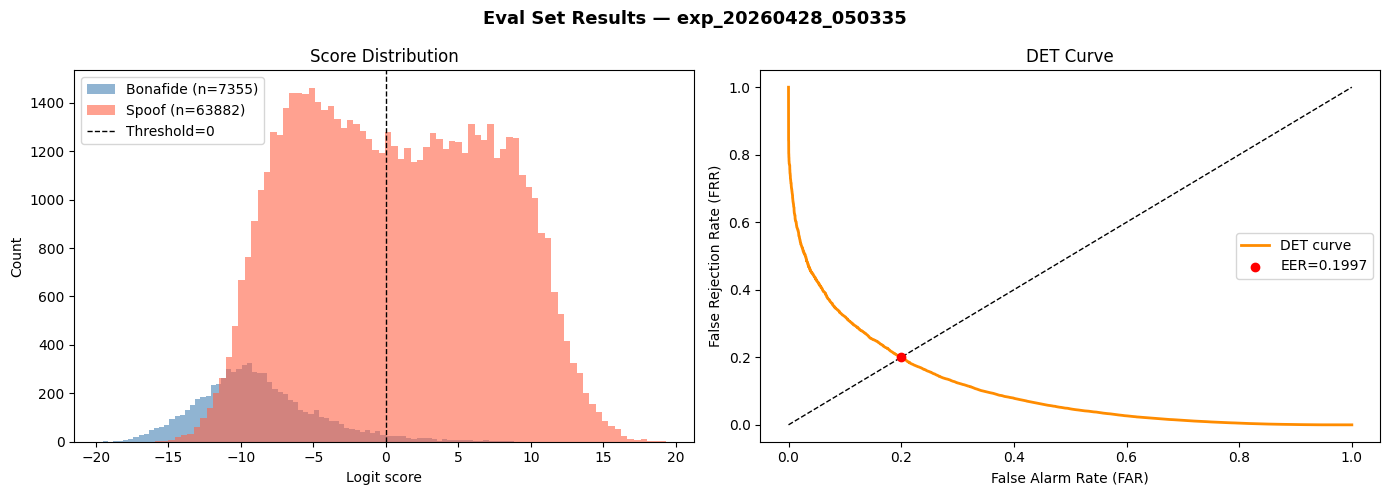

✓ Plots saved: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260428_050335_eval_plots.png


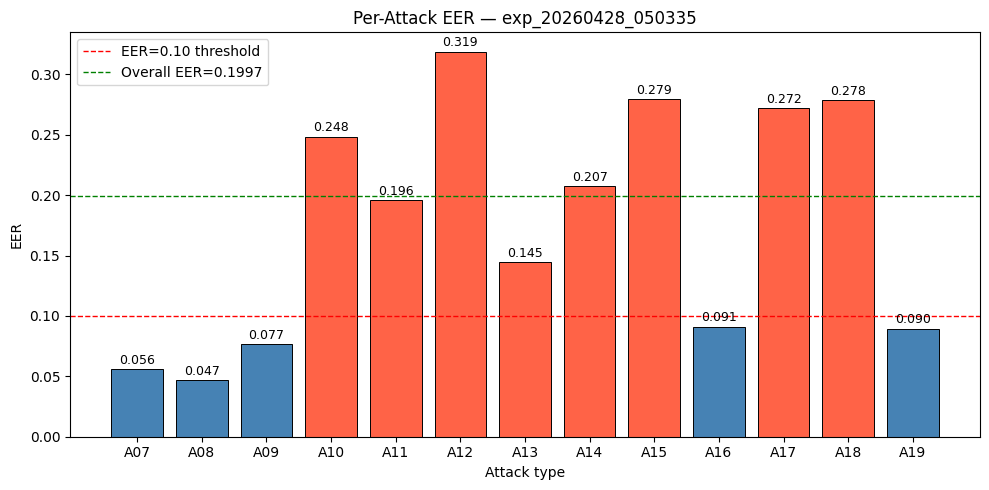

✓ Per-attack plot saved: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260428_050335_per_attack_eer.png

PHASE 9: Confusion matrix + CSV logging

--- Confusion Matrix: Eval set (final) ---
                  Predicted
               Bonafide   Spoof
Actual Bonafide     5888    1467
       Spoof       12763   51119
TN=5888  FP=1467  FN=12763  TP=51119
Sensitivity (TPR): 0.8002   Specificity (TNR): 0.8005
✓ CSV log updated: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260428_050335_metrics.csv

FINAL RESULTS SUMMARY
  Experiment      : exp_20260428_050335
  Checkpoint epoch: 19
  Accuracy        : 0.8002
  AUC             : 0.8898
  EER             : 0.1997
  EER threshold   : -5.8388
  Precision       : 0.9721
  Recall          : 0.8002
  F1              : 0.8778
  min-tDCF        : 0.1431  ✓ Competitive result (< 0.20)
  Inference time  : 1404.1s (23.4 min)

  Score file      : C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp

In [22]:
# Cell 27A  — Final evaluation on LA_eval

import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve
from torch.utils.data import DataLoader as _DL
from collections import defaultdict

evaluate                       = _require_global('evaluate')
_check_score_direction         = _require_global('_check_score_direction')
write_scores_in_protocol_order = _require_global('write_scores_in_protocol_order')
parse_asv_scores               = _require_global('parse_asv_scores')
asv_error_rates                = _require_global('asv_error_rates')
min_tdcf                       = _require_global('min_tdcf')
append_csv_row                 = _require_global('append_csv_row')
print_confusion_matrix         = _require_global('print_confusion_matrix')
eer_from_scores                = _require_global('eer_from_scores')

model           = _require_global('model')
DEVICE          = _require_global('DEVICE')
BEST_MODEL_PATH = _require_global('BEST_MODEL_PATH')
# FIX: eval_loader is unused in this cell — fast_eval_loader replaces it.
# Removed the pointless _require_global('eval_loader') call.
eval_records    = _require_global('eval_records')
EVAL_SCORE_PATH = _require_global('EVAL_SCORE_PATH')
ASV_EVAL_SCORES = _require_global('ASV_EVAL_SCORES')
MAX_EPOCHS      = _require_global('MAX_EPOCHS')
EXPERIMENT_ID   = _require_global('EXPERIMENT_ID')
BATCH_SIZE      = _require_global('BATCH_SIZE')
CSV_LOG         = _require_global('CSV_LOG')
ARTIFACT_DIR    = _require_global('ARTIFACT_DIR')
eval_ds         = _require_global('eval_ds')
EVAL_AUDIO_DIR  = _require_global('EVAL_AUDIO_DIR')
FEATURE_CACHE_DIR = _require_global('FEATURE_CACHE_DIR')
_parallel_prewarm = _require_global('_parallel_prewarm')
_worker_init_fn   = _require_global('_worker_init_fn')
CUDA_NUM_WORKERS  = _require_global('CUDA_NUM_WORKERS')
BiLSTMAttentionCM = _require_global('BiLSTMAttentionCM')
SR          = _require_global('SR')
N_MFCC      = _require_global('N_MFCC')
N_FFT       = _require_global('N_FFT')
WIN_LENGTH  = _require_global('WIN_LENGTH')
HOP_LENGTH  = _require_global('HOP_LENGTH')
VAD_THR_FACTOR = _require_global('VAD_THR_FACTOR')
FEAT_DIM    = _require_global('FEAT_DIM')

# ── PHASE 1: EVAL cache pre-warm ────────────────────────────────────────────
print('=' * 60)
print('PHASE 1: EVAL cache pre-warm')
print('=' * 60)
t_prewarm = time.time()

_parallel_prewarm(
    eval_records, EVAL_AUDIO_DIR, FEATURE_CACHE_DIR,
    SR, N_MFCC, N_FFT, WIN_LENGTH, HOP_LENGTH,
    VAD_THR_FACTOR, FEAT_DIM, label='EVAL',
)
print(f'\u2713 Pre-warm complete in {time.time() - t_prewarm:.1f}s')

# ── PHASE 2: Fast eval loader ────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 2: Building fast eval loader')
print('=' * 60)

_eval_nw = 0 if sys.platform == 'win32' else CUDA_NUM_WORKERS
fast_eval_loader = _DL(
    eval_ds,
    batch_size=128,
    shuffle=False,
    num_workers=_eval_nw,
    pin_memory=_eval_nw > 0,
    persistent_workers=_eval_nw > 0,
    prefetch_factor=2 if _eval_nw > 0 else None,
    worker_init_fn=_worker_init_fn if _eval_nw > 0 else None,
)
print(f'\u2713 Fast eval loader: batch_size=128, num_workers={_eval_nw} (0=Windows spawn-safe)')

# ── PHASE 3: Load best model checkpoint ─────────────────────────────────────
print()
print('=' * 60)
print('PHASE 3: Loading best model checkpoint')
print('=' * 60)

ckpt  = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True)
model = BiLSTMAttentionCM().to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'\u2713 Loaded checkpoint from epoch {ckpt["epoch"]} (val EER={ckpt["val_eer"]:.4f})')

# ── PHASE 4: Inference ───────────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 4: Running inference on eval set')
print('=' * 60)

eval_t0 = time.time()
eval_m, eval_logits, eval_labels, eval_utts, eval_label_str = evaluate(
    model, fast_eval_loader, DEVICE, verbose=True
)
eval_elapsed = time.time() - eval_t0
print(f'\u2713 Inference complete in {eval_elapsed:.1f}s '
      f'({len(eval_records)/eval_elapsed:.0f} utterances/sec)')

# ── PHASE 5: Sanity checks ───────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 5: Sanity checks')
print('=' * 60)

assert len(eval_logits) == len(eval_records), 'Length mismatch before final tDCF scoring.'
print(f'\u2713 Score count matches protocol: {len(eval_logits)}/{len(eval_records)}')

direction_ok = _check_score_direction(eval_logits, eval_labels, epoch=MAX_EPOCHS)
if direction_ok:
    print('\u2713 Score direction correct (spoof > bonafide)')
else:
    print('\u26a0  Score direction warning — check direction_warnings.log')

print(f'\u2713 Logit stats — min: {eval_logits.min():.4f}  '
      f'max: {eval_logits.max():.4f}  '
      f'mean: {eval_logits.mean():.4f}  '
      f'std: {float(eval_logits.astype(np.float64).std()):.4f}')

if eval_logits.std() < 0.01:
    print('\u26a0  Logit std near zero — model may be predicting a constant.')
else:
    print('\u2713 Logit spread looks healthy (std > 0.01)')

# ── PHASE 6: Score writing + tDCF ────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 6: Score writing + tDCF computation')
print('=' * 60)

write_scores_in_protocol_order(eval_records, eval_logits, EVAL_SCORE_PATH)
print(f'\u2713 Eval scores written: {EVAL_SCORE_PATH}')

asv_eval = parse_asv_scores(ASV_EVAL_SCORES)
assert len(asv_eval['target'])    > 0
assert len(asv_eval['nontarget']) > 0
assert len(asv_eval['spoof'])     > 0
print(f'\u2713 ASV scores loaded — '
      f'target: {len(asv_eval["target"])}, '
      f'nontarget: {len(asv_eval["nontarget"])}, '
      f'spoof: {len(asv_eval["spoof"])}')

asv_eval_stats = asv_error_rates(asv_eval)
final_min_tdcf = min_tdcf(eval_labels, eval_logits, asv_eval_stats)

if final_min_tdcf < 0.10:
    tdcf_verdict = '\u2713 Excellent result (< 0.10)'
elif final_min_tdcf < 0.20:
    tdcf_verdict = '\u2713 Competitive result (< 0.20)'
elif final_min_tdcf < 0.40:
    tdcf_verdict = '\u26a0  Moderate result (< 0.40)'
else:
    tdcf_verdict = '\u26a0  Weak result (\u2265 0.40)'
print(f'\u2713 Final min-tDCF: {final_min_tdcf:.4f}  {tdcf_verdict}')

# ── PHASE 7: Per-attack EER breakdown ────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 7: Per-attack-type EER breakdown')
print('=' * 60)

attack_logits  = defaultdict(list)
attack_labels  = defaultdict(list)
for rec, logit, label in zip(eval_records, eval_logits, eval_labels):
    attack_logits[rec['attack']].append(logit)
    attack_labels[rec['attack']].append(label)

# Build bonafide pool from all eval records (label==0)
_bona_logits = eval_logits[eval_labels == 0]
_bona_labels = np.zeros(len(_bona_logits), dtype=np.int32)

attack_eers = {}
for attack in sorted(attack_logits.keys()):
    a_logits = np.array(attack_logits[attack])
    a_labels = np.array(attack_labels[attack])
    # Skip the bonafide group itself (stored under '-' or label==0)
    if np.all(a_labels == 0):
        print(f'  {attack:<6}  {len(a_logits):>6} utterances  (bonafide pool — skipped)')
        continue
    # Pair this attack's spoof scores against the full bonafide pool
    paired_logits = np.concatenate([_bona_logits, a_logits])
    paired_labels = np.concatenate([_bona_labels, np.ones(len(a_logits), dtype=np.int32)])
    a_eer, _ = eer_from_scores(paired_labels, paired_logits)
    attack_eers[attack] = a_eer
    verdict = '\u2713' if a_eer < 0.10 else '\u26a0 '
    print(f'  {attack:<6}  {len(a_logits):>6} utterances  EER={a_eer:.4f}  {verdict}')

# ── PHASE 8: Plots ───────────────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 8: Generating plots')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Eval Set Results — {EXPERIMENT_ID}', fontsize=13, fontweight='bold')

bona_scores  = eval_logits[eval_labels == 0]
spoof_scores = eval_logits[eval_labels == 1]

axes[0].hist(bona_scores,  bins=80, alpha=0.6, color='steelblue', label=f'Bonafide (n={len(bona_scores)})')
axes[0].hist(spoof_scores, bins=80, alpha=0.6, color='tomato',    label=f'Spoof (n={len(spoof_scores)})')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, label='Threshold=0')
axes[0].set_xlabel('Logit score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')
axes[0].legend()

fpr, tpr, thresholds = roc_curve(eval_labels, eval_logits)
fnr = 1 - tpr
axes[1].plot(fpr, fnr, color='darkorange', linewidth=2, label='DET curve')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
eer_idx = np.nanargmin(np.abs(fpr - fnr))
axes[1].scatter(fpr[eer_idx], fnr[eer_idx], color='red', zorder=5,
                label=f'EER={eval_m["eer"]:.4f}')
axes[1].set_xlabel('False Alarm Rate (FAR)')
axes[1].set_ylabel('False Rejection Rate (FRR)')
axes[1].set_title('DET Curve')
axes[1].legend()

plt.tight_layout()
plot_path = ARTIFACT_DIR / f'{EXPERIMENT_ID}_eval_plots.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Plots saved: {plot_path}')

if attack_eers:
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    attacks = list(attack_eers.keys())
    eers    = [attack_eers[a] for a in attacks]
    colors  = ['tomato' if e >= 0.10 else 'steelblue' for e in eers]
    bars    = ax2.bar(attacks, eers, color=colors, edgecolor='black', linewidth=0.7)
    ax2.axhline(0.10, color='red',   linestyle='--', linewidth=1, label='EER=0.10 threshold')
    ax2.axhline(eval_m['eer'], color='green', linestyle='--', linewidth=1,
                label=f'Overall EER={eval_m["eer"]:.4f}')
    ax2.set_xlabel('Attack type')
    ax2.set_ylabel('EER')
    ax2.set_title(f'Per-Attack EER — {EXPERIMENT_ID}')
    ax2.legend()
    for bar, eer_val in zip(bars, eers):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{eer_val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    attack_plot_path = ARTIFACT_DIR / f'{EXPERIMENT_ID}_per_attack_eer.png'
    plt.savefig(attack_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\u2713 Per-attack plot saved: {attack_plot_path}')

# ── PHASE 9: Confusion matrix + CSV logging ──────────────────────────────────
print()
print('=' * 60)
print('PHASE 9: Confusion matrix + CSV logging')
print('=' * 60)

print_confusion_matrix(eval_labels, eval_logits, title='Eval set (final)')

append_csv_row(CSV_LOG, [
    EXPERIMENT_ID, 'BiLSTMAttention', 'MFCC40+delta+delta2', 'light_vad', 'attention_pool',
    'final', '', eval_m['accuracy'], eval_m['auc'], eval_m['eer'], eval_m['eer_threshold'],
    eval_m['precision'], eval_m['recall'], eval_m['f1'],
    '', BATCH_SIZE, eval_elapsed, final_min_tdcf,
])
print(f'\u2713 CSV log updated: {CSV_LOG}')

# ── FINAL SUMMARY ────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Experiment      : {EXPERIMENT_ID}')
print(f'  Checkpoint epoch: {ckpt["epoch"]}')
print(f'  Accuracy        : {eval_m["accuracy"]:.4f}')
print(f'  AUC             : {eval_m["auc"]:.4f}')
print(f'  EER             : {eval_m["eer"]:.4f}')
print(f'  EER threshold   : {eval_m["eer_threshold"]:.4f}')
print(f'  Precision       : {eval_m["precision"]:.4f}')
print(f'  Recall          : {eval_m["recall"]:.4f}')
print(f'  F1              : {eval_m["f1"]:.4f}')
print(f'  min-tDCF        : {final_min_tdcf:.4f}  {tdcf_verdict}')
print(f'  Inference time  : {eval_elapsed:.1f}s ({eval_elapsed/60:.1f} min)')
print()
print(f'  Score file      : {EVAL_SCORE_PATH}')
print(f'  CSV log         : {CSV_LOG}')
print(f'  Best model      : {BEST_MODEL_PATH}')
print(f'  Plots           : {ARTIFACT_DIR}')
print('=' * 60)



PHASE 1: DEV cache pre-warm
DEV cache: 24844/24844 cached, 0 to build.
All cached — skipping pre-warm.
✓ Pre-warm complete in 3.6s

PHASE 2: Building fast dev loader
✓ Fast dev loader: batch_size=128, num_workers=0 (0=Windows spawn-safe)

PHASE 3: Loading best model checkpoint
✓ Loaded checkpoint from epoch 19 (val EER=0.0817)

PHASE 4: Running inference on dev set
  Eval batch 0/195
  Eval batch 50/195
  Eval batch 100/195
  Eval batch 150/195
✓ Inference complete in 252.7s (98 utterances/sec)

PHASE 5: Sanity checks
✓ Score count matches protocol: 24844/24844
✓ Score direction correct (spoof > bonafide)
✓ Logit stats — min: -18.8594  max: 22.7344  mean: 6.8906  std: 7.5144

PHASE 6: Score writing + tDCF computation
✓ Dev scores written: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260428_050335_dev_scores.txt
✓ Dev min-tDCF: 0.0593  ✓ Excellent result (< 0.10)

PHASE 7: Per-attack-type EER breakdown
  -         2548 utterances  (bonafide pool — skipped)
  A01  

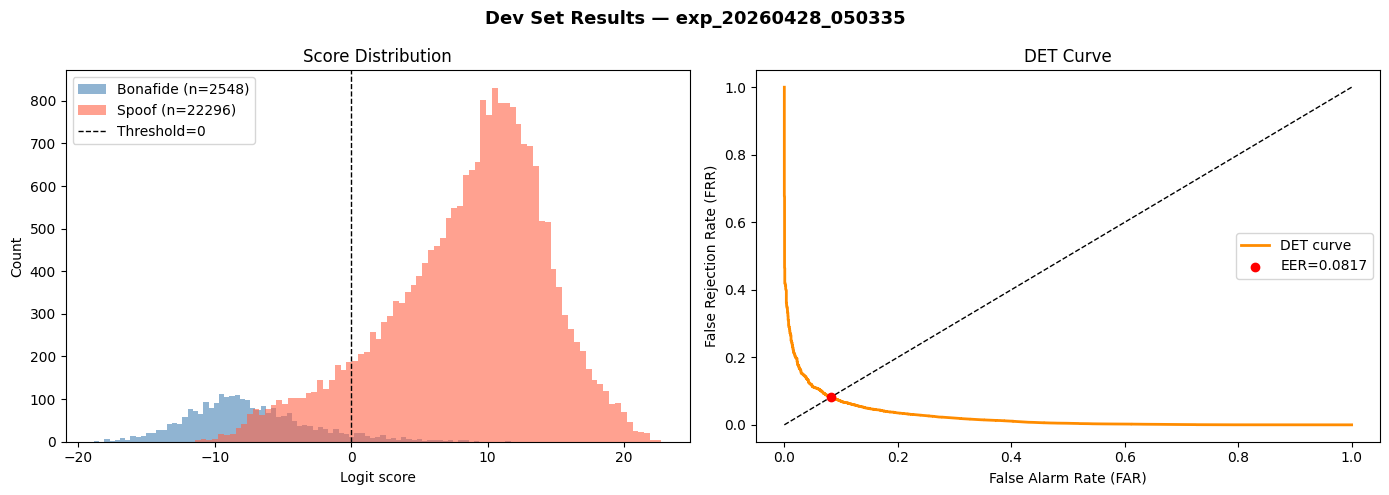

✓ Plots saved: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260428_050335_dev_plots.png


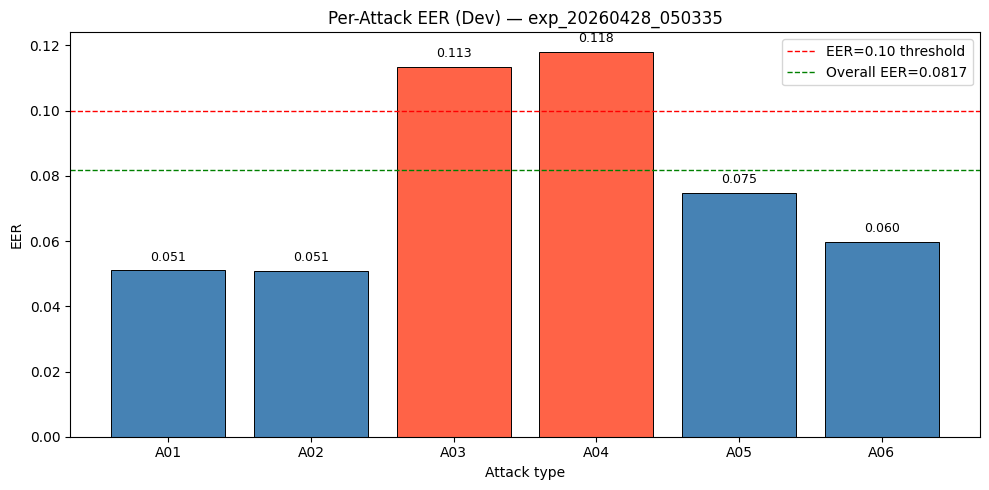

✓ Per-attack plot saved: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260428_050335_dev_per_attack_eer.png

PHASE 9: Confusion matrix

--- Confusion Matrix: Dev set (final) ---
                  Predicted
               Bonafide   Spoof
Actual Bonafide     2340     208
       Spoof        1821   20475
TN=2340  FP=208  FN=1821  TP=20475
Sensitivity (TPR): 0.9183   Specificity (TNR): 0.9184

DEV SET FINAL RESULTS SUMMARY
  Experiment      : exp_20260428_050335
  Checkpoint epoch: 19
  Accuracy        : 0.9183
  AUC             : 0.9746
  EER             : 0.0817
  EER threshold   : -0.7990
  Precision       : 0.9899
  Recall          : 0.9183
  F1              : 0.9528
  min-tDCF        : 0.0593  ✓ Excellent result (< 0.10)
  Inference time  : 252.7s (4.2 min)

  Score file      : C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260428_050335_dev_scores.txt
  Plots           : C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts


In [23]:
# Cell 27B — Final evaluation on LA_dev (mirrors Cell 27)

import sys
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from torch.utils.data import DataLoader as _DL

# ── Require globals ──────────────────────────────────────────────────────────
evaluate                       = _require_global('evaluate')
_check_score_direction         = _require_global('_check_score_direction')
write_scores_in_protocol_order = _require_global('write_scores_in_protocol_order')
parse_asv_scores               = _require_global('parse_asv_scores')
asv_error_rates                = _require_global('asv_error_rates')
min_tdcf                       = _require_global('min_tdcf')
append_csv_row                 = _require_global('append_csv_row')
print_confusion_matrix         = _require_global('print_confusion_matrix')
eer_from_scores                = _require_global('eer_from_scores')
model                          = _require_global('model')
DEVICE                         = _require_global('DEVICE')
BEST_MODEL_PATH                = _require_global('BEST_MODEL_PATH')
dev_records                    = _require_global('dev_records')
dev_ds                         = _require_global('dev_ds')
DEV_SCORE_PATH                 = _require_global('DEV_SCORE_PATH')
ASV_DEV_SCORES                 = _require_global('ASV_DEV_SCORES')
EXPERIMENT_ID                  = _require_global('EXPERIMENT_ID')
BATCH_SIZE                     = _require_global('BATCH_SIZE')
CSV_LOG                        = _require_global('CSV_LOG')
ARTIFACT_DIR                   = _require_global('ARTIFACT_DIR')
CUDA_NUM_WORKERS               = _require_global('CUDA_NUM_WORKERS')
_worker_init_fn                = _require_global('_worker_init_fn')
BiLSTMAttentionCM              = _require_global('BiLSTMAttentionCM')
_parallel_prewarm              = _require_global('_parallel_prewarm')
DEV_AUDIO_DIR                  = _require_global('DEV_AUDIO_DIR')
FEATURE_CACHE_DIR              = _require_global('FEATURE_CACHE_DIR')
SR                             = _require_global('SR')
N_MFCC                        = _require_global('N_MFCC')
N_FFT                         = _require_global('N_FFT')
WIN_LENGTH                     = _require_global('WIN_LENGTH')
HOP_LENGTH                     = _require_global('HOP_LENGTH')
VAD_THR_FACTOR                 = _require_global('VAD_THR_FACTOR')
FEAT_DIM                       = _require_global('FEAT_DIM')
MAX_EPOCHS                     = _require_global('MAX_EPOCHS')

# ── PHASE 1: DEV cache pre-warm ──────────────────────────────────────────────
print('=' * 60)
print('PHASE 1: DEV cache pre-warm')
print('=' * 60)
t_prewarm = time.time()
_parallel_prewarm(
    dev_records, DEV_AUDIO_DIR, FEATURE_CACHE_DIR,
    SR, N_MFCC, N_FFT, WIN_LENGTH, HOP_LENGTH,
    VAD_THR_FACTOR, FEAT_DIM, label='DEV',
)
print(f'\u2713 Pre-warm complete in {time.time() - t_prewarm:.1f}s')

# ── PHASE 2: Fast dev loader ─────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 2: Building fast dev loader')
print('=' * 60)
_dev_nw = 0 if sys.platform == 'win32' else CUDA_NUM_WORKERS
fast_dev_eval_loader = _DL(
    dev_ds,
    batch_size=128,
    shuffle=False,
    num_workers=_dev_nw,
    pin_memory=_dev_nw > 0,
    persistent_workers=_dev_nw > 0,
    prefetch_factor=2 if _dev_nw > 0 else None,
    worker_init_fn=_worker_init_fn if _dev_nw > 0 else None,
)
print(f'\u2713 Fast dev loader: batch_size=128, num_workers={_dev_nw} (0=Windows spawn-safe)')

# ── PHASE 3: Load best model checkpoint ─────────────────────────────────────
print()
print('=' * 60)
print('PHASE 3: Loading best model checkpoint')
print('=' * 60)
ckpt  = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True)
model = BiLSTMAttentionCM().to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'\u2713 Loaded checkpoint from epoch {ckpt["epoch"]} (val EER={ckpt["val_eer"]:.4f})')

# ── PHASE 4: Inference ───────────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 4: Running inference on dev set')
print('=' * 60)
dev_t0 = time.time()
dev_m, dev_logits, dev_labels, dev_utts, dev_label_str = evaluate(
    model, fast_dev_eval_loader, DEVICE, verbose=True
)
dev_elapsed = time.time() - dev_t0
print(f'\u2713 Inference complete in {dev_elapsed:.1f}s '
      f'({len(dev_records)/dev_elapsed:.0f} utterances/sec)')

# ── PHASE 5: Sanity checks ───────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 5: Sanity checks')
print('=' * 60)
assert len(dev_logits) == len(dev_records), 'Length mismatch.'
print(f'\u2713 Score count matches protocol: {len(dev_logits)}/{len(dev_records)}')
direction_ok = _check_score_direction(dev_logits, dev_labels, epoch=MAX_EPOCHS)
if direction_ok:
    print('\u2713 Score direction correct (spoof > bonafide)')
else:
    print('\u26a0  Score direction warning')
print(f'\u2713 Logit stats — min: {dev_logits.min():.4f}  '
      f'max: {dev_logits.max():.4f}  '
      f'mean: {dev_logits.mean():.4f}  '
      f'std: {float(dev_logits.astype(np.float64).std()):.4f}')

# ── PHASE 6: Score writing + tDCF ────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 6: Score writing + tDCF computation')
print('=' * 60)
write_scores_in_protocol_order(dev_records, dev_logits, DEV_SCORE_PATH)
print(f'\u2713 Dev scores written: {DEV_SCORE_PATH}')
asv_dev = parse_asv_scores(ASV_DEV_SCORES)
asv_dev_stats = asv_error_rates(asv_dev)
dev_min_tdcf  = min_tdcf(dev_labels, dev_logits, asv_dev_stats)
if dev_min_tdcf < 0.10:
    tdcf_verdict = '\u2713 Excellent result (< 0.10)'
elif dev_min_tdcf < 0.20:
    tdcf_verdict = '\u2713 Competitive result (< 0.20)'
elif dev_min_tdcf < 0.40:
    tdcf_verdict = '\u26a0  Moderate result (< 0.40)'
else:
    tdcf_verdict = '\u26a0  Weak result (\u2265 0.40)'
print(f'\u2713 Dev min-tDCF: {dev_min_tdcf:.4f}  {tdcf_verdict}')

# ── PHASE 7: Per-attack EER breakdown ────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 7: Per-attack-type EER breakdown')
print('=' * 60)
attack_logits = defaultdict(list)
attack_labels = defaultdict(list)
for rec, logit, label in zip(dev_records, dev_logits, dev_labels):
    attack_logits[rec['attack']].append(logit)
    attack_labels[rec['attack']].append(label)

_bona_logits = dev_logits[dev_labels == 0]
_bona_labels = np.zeros(len(_bona_logits), dtype=np.int32)
attack_eers  = {}
for attack in sorted(attack_logits.keys()):
    a_logits = np.array(attack_logits[attack])
    a_labels = np.array(attack_labels[attack])
    if np.all(a_labels == 0):
        print(f'  {attack:<6}  {len(a_logits):>6} utterances  (bonafide pool — skipped)')
        continue
    paired_logits = np.concatenate([_bona_logits, a_logits])
    paired_labels = np.concatenate([_bona_labels, np.ones(len(a_logits), dtype=np.int32)])
    a_eer, _ = eer_from_scores(paired_labels, paired_logits)
    attack_eers[attack] = a_eer
    verdict = '\u2713' if a_eer < 0.10 else '\u26a0 '
    print(f'  {attack:<6}  {len(a_logits):>6} utterances  EER={a_eer:.4f}  {verdict}')

# ── PHASE 8: Plots ───────────────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 8: Generating plots')
print('=' * 60)
from sklearn.metrics import roc_curve as _roc_curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Dev Set Results — {EXPERIMENT_ID}', fontsize=13, fontweight='bold')
bona_scores  = dev_logits[dev_labels == 0]
spoof_scores = dev_logits[dev_labels == 1]
axes[0].hist(bona_scores,  bins=80, alpha=0.6, color='steelblue', label=f'Bonafide (n={len(bona_scores)})')
axes[0].hist(spoof_scores, bins=80, alpha=0.6, color='tomato',    label=f'Spoof (n={len(spoof_scores)})')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, label='Threshold=0')
axes[0].set_xlabel('Logit score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')
axes[0].legend()
fpr, tpr, thresholds = _roc_curve(dev_labels, dev_logits)
fnr = 1 - tpr
axes[1].plot(fpr, fnr, color='darkorange', linewidth=2, label='DET curve')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
eer_idx = np.nanargmin(np.abs(fpr - fnr))
axes[1].scatter(fpr[eer_idx], fnr[eer_idx], color='red', zorder=5,
                label=f'EER={dev_m["eer"]:.4f}')
axes[1].set_xlabel('False Alarm Rate (FAR)')
axes[1].set_ylabel('False Rejection Rate (FRR)')
axes[1].set_title('DET Curve')
axes[1].legend()
plt.tight_layout()
dev_plot_path = ARTIFACT_DIR / f'{EXPERIMENT_ID}_dev_plots.png'
plt.savefig(dev_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Plots saved: {dev_plot_path}')

if attack_eers:
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    attacks = list(attack_eers.keys())
    eers    = [attack_eers[a] for a in attacks]
    colors  = ['tomato' if e >= 0.10 else 'steelblue' for e in eers]
    bars    = ax2.bar(attacks, eers, color=colors, edgecolor='black', linewidth=0.7)
    ax2.axhline(0.10, color='red',   linestyle='--', linewidth=1, label='EER=0.10 threshold')
    ax2.axhline(dev_m['eer'], color='green', linestyle='--', linewidth=1,
                label=f'Overall EER={dev_m["eer"]:.4f}')
    ax2.set_xlabel('Attack type')
    ax2.set_ylabel('EER')
    ax2.set_title(f'Per-Attack EER (Dev) — {EXPERIMENT_ID}')
    ax2.legend()
    for bar, eer_val in zip(bars, eers):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{eer_val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    dev_attack_plot = ARTIFACT_DIR / f'{EXPERIMENT_ID}_dev_per_attack_eer.png'
    plt.savefig(dev_attack_plot, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\u2713 Per-attack plot saved: {dev_attack_plot}')

# ── PHASE 9: Confusion matrix ────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 9: Confusion matrix')
print('=' * 60)
print_confusion_matrix(dev_labels, dev_logits, title='Dev set (final)')

# ── FINAL SUMMARY ────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('DEV SET FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Experiment      : {EXPERIMENT_ID}')
print(f'  Checkpoint epoch: {ckpt["epoch"]}')
print(f'  Accuracy        : {dev_m["accuracy"]:.4f}')
print(f'  AUC             : {dev_m["auc"]:.4f}')
print(f'  EER             : {dev_m["eer"]:.4f}')
print(f'  EER threshold   : {dev_m["eer_threshold"]:.4f}')
print(f'  Precision       : {dev_m["precision"]:.4f}')
print(f'  Recall          : {dev_m["recall"]:.4f}')
print(f'  F1              : {dev_m["f1"]:.4f}')
print(f'  min-tDCF        : {dev_min_tdcf:.4f}  {tdcf_verdict}')
print(f'  Inference time  : {dev_elapsed:.1f}s ({dev_elapsed/60:.1f} min)')
print()
print(f'  Score file      : {DEV_SCORE_PATH}')
print(f'  Plots           : {ARTIFACT_DIR}')
print('=' * 60)


PHASE 1: Parsing ASVspoof2021 LA protocol
✓ Protocol parsed: 148176 utterances (bonafide=14816, spoof=133360)

PHASE 2: Cache pre-warm
EVAL2021 cache: 148176/148176 cached, 0 to build.
All cached — skipping pre-warm.
✓ Pre-warm complete in 19.0s

PHASE 3: Building eval loader
✓ Eval loader: batch_size=128, num_workers=0 (0=Windows spawn-safe)

PHASE 4: Loading best model checkpoint
✓ Loaded checkpoint from epoch 19 (val EER=0.0817)

PHASE 5: Running inference on 2021 eval set
  Eval batch 0/1158
  Eval batch 50/1158
  Eval batch 100/1158
  Eval batch 150/1158
  Eval batch 200/1158
  Eval batch 250/1158
  Eval batch 300/1158
  Eval batch 350/1158
  Eval batch 400/1158
  Eval batch 450/1158
  Eval batch 500/1158
  Eval batch 550/1158
  Eval batch 600/1158
  Eval batch 650/1158
  Eval batch 700/1158
  Eval batch 750/1158
  Eval batch 800/1158
  Eval batch 850/1158
  Eval batch 900/1158
  Eval batch 950/1158
  Eval batch 1000/1158
  Eval batch 1050/1158
  Eval batch 1100/1158
  Eval batch 

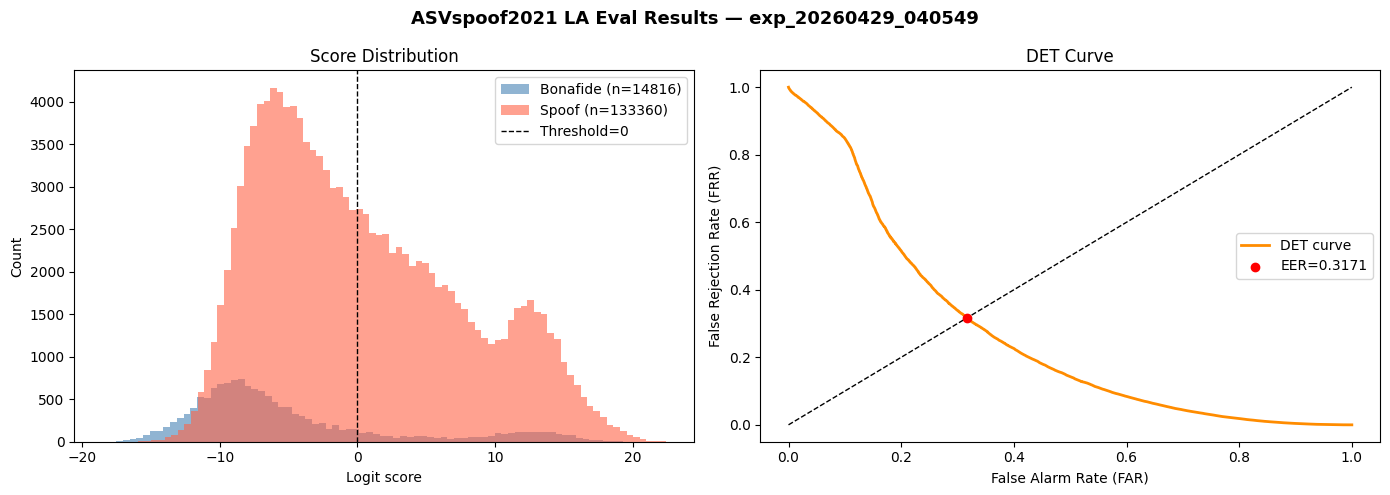

✓ Plots saved: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260429_040549_eval2021_plots.png


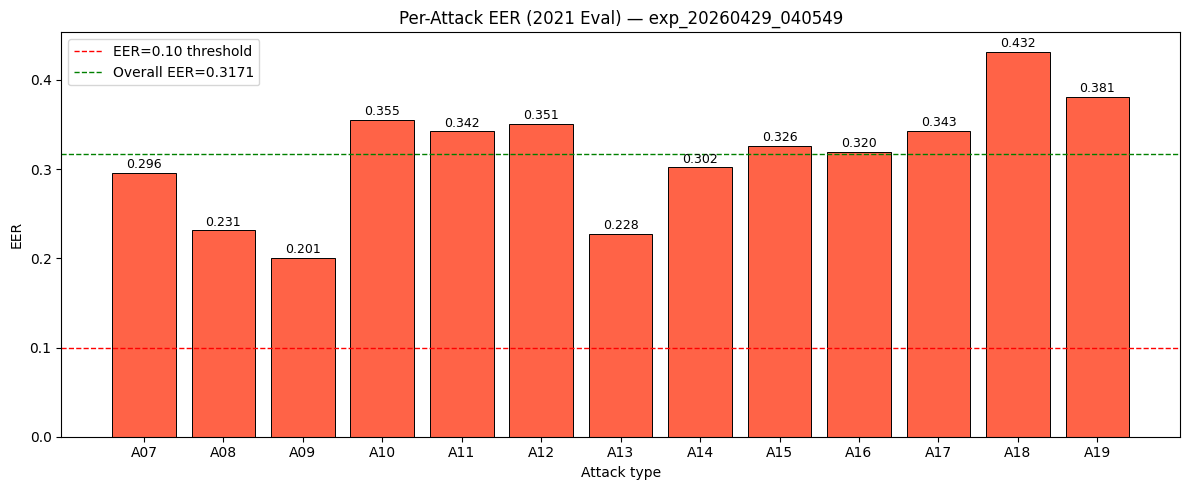

✓ Per-attack plot saved: C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260429_040549_eval2021_per_attack_eer.png

PHASE 10: Confusion matrix

--- Confusion Matrix: ASVspoof2021 LA Eval (final) ---
                  Predicted
               Bonafide   Spoof
Actual Bonafide    10120    4696
       Spoof       42318   91042
TN=10120  FP=4696  FN=42318  TP=91042
Sensitivity (TPR): 0.6827   Specificity (TNR): 0.6830

ASVspoof2021 LA EVAL — FINAL RESULTS SUMMARY
  Experiment      : exp_20260429_040549
  Checkpoint epoch: 19
  Accuracy        : 0.6827
  AUC             : 0.7313
  EER             : 0.3171
  EER threshold   : -4.6365
  Precision       : 0.9509
  Recall          : 0.6827
  F1              : 0.7948
  min-tDCF        : 0.2415  ⚠  Moderate result (< 0.40)
  Inference time  : 3100.7s (51.7 min)

  Score file      : C:\Coding\CollegeProjects\DeepFakeProject\LstmFiles\artifacts\exp_20260429_040549_eval2021_scores.txt
  Plots           : C:\Coding\CollegeProjects\

In [17]:
# Cell 27C — Final evaluation on ASVspoof2021 LA eval

import sys
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from torch.utils.data import DataLoader as _DL
from sklearn.metrics import roc_curve

evaluate                       = _require_global('evaluate')
_check_score_direction         = _require_global('_check_score_direction')
write_scores_in_protocol_order = _require_global('write_scores_in_protocol_order')
asv_error_rates                = _require_global('asv_error_rates')
min_tdcf                       = _require_global('min_tdcf')
append_csv_row                 = _require_global('append_csv_row')
print_confusion_matrix         = _require_global('print_confusion_matrix')
eer_from_scores                = _require_global('eer_from_scores')
_parallel_prewarm              = _require_global('_parallel_prewarm')
_worker_init_fn                = _require_global('_worker_init_fn')
BiLSTMAttentionCM              = _require_global('BiLSTMAttentionCM')
ASVspoof2019Dataset            = _require_global('ASVspoofCMFeatureDataset')
model                          = _require_global('model')
DEVICE                         = _require_global('DEVICE')
BEST_MODEL_PATH                = _require_global('BEST_MODEL_PATH')
EXPERIMENT_ID                  = _require_global('EXPERIMENT_ID')
ARTIFACT_DIR                   = _require_global('ARTIFACT_DIR')
CSV_LOG                        = _require_global('CSV_LOG')
BATCH_SIZE                     = _require_global('BATCH_SIZE')
CUDA_NUM_WORKERS               = _require_global('CUDA_NUM_WORKERS')
FEATURE_CACHE_DIR              = _require_global('FEATURE_CACHE_DIR')
MAX_EPOCHS                     = _require_global('MAX_EPOCHS')
SR                             = _require_global('SR')
N_MFCC                        = _require_global('N_MFCC')
N_FFT                         = _require_global('N_FFT')
WIN_LENGTH                     = _require_global('WIN_LENGTH')
HOP_LENGTH                     = _require_global('HOP_LENGTH')
VAD_THR_FACTOR                 = _require_global('VAD_THR_FACTOR')
FEAT_DIM                       = _require_global('FEAT_DIM')

# ── Paths ─────────────────────────────────────────────────────────────────────
EVAL21_ROOT       = Path(r'C:/Coding/CollegeProjects/DeepFakeProject/LstmFiles/ASVspoof2021_LA_eval')
EVAL21_AUDIO_DIR  = EVAL21_ROOT / 'flac'
EVAL21_META       = EVAL21_ROOT / 'keys/LA/CM/trial_metadata.txt'
EVAL21_ASV_META   = EVAL21_ROOT / 'keys/LA/ASV/trial_metadata.txt'
EVAL21_ASV_SCORE  = EVAL21_ROOT / 'keys/LA/ASV/ASVTorch_Kaldi/score.txt'
EVAL21_SCORE_PATH = ARTIFACT_DIR / f'{EXPERIMENT_ID}_eval2021_scores.txt'

# Override BEST_MODEL_PATH to point to your actual trained model
BEST_MODEL_PATH = Path(r'C:/Coding/CollegeProjects/DeepFakeProject/LstmFiles/artifacts/exp_20260426_205924_best_model.pt')

# ── PHASE 1: Parse 2021 protocol ─────────────────────────────────────────────
print('=' * 60)
print('PHASE 1: Parsing ASVspoof2021 LA protocol')
print('=' * 60)

eval21_records = []
with open(EVAL21_META) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 8:
            continue
        spk_id, utt_id, codec, env, attack, label_str, trim, subset = parts[:8]
        if subset != 'eval':
            continue
        eval21_records.append({
            'utt_id':    utt_id,
            'speaker':   spk_id,
            'attack':    attack,
            'label':     0 if label_str == 'bonafide' else 1,
            'label_str': label_str,
            'codec':     codec,
            'env':       env,
        })

n_bona  = sum(1 for r in eval21_records if r['label'] == 0)
n_spoof = sum(1 for r in eval21_records if r['label'] == 1)
print(f'✓ Protocol parsed: {len(eval21_records)} utterances '
      f'(bonafide={n_bona}, spoof={n_spoof})')

# ── PHASE 2: Cache pre-warm ───────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 2: Cache pre-warm')
print('=' * 60)
t_prewarm = time.time()
_parallel_prewarm(
    eval21_records, EVAL21_AUDIO_DIR, FEATURE_CACHE_DIR,
    SR, N_MFCC, N_FFT, WIN_LENGTH, HOP_LENGTH,
    VAD_THR_FACTOR, FEAT_DIM, label='EVAL2021',
)
print(f'✓ Pre-warm complete in {time.time() - t_prewarm:.1f}s')

# ── PHASE 3: Build DataLoader ─────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 3: Building eval loader')
print('=' * 60)
eval21_ds = ASVspoof2019Dataset(
    records     = eval21_records,
    audio_dir   = EVAL21_AUDIO_DIR,
    random_crop = False,
)
_e21_nw = 0 if sys.platform == 'win32' else CUDA_NUM_WORKERS
fast_eval21_loader = _DL(
    eval21_ds,
    batch_size=128,
    shuffle=False,
    num_workers=_e21_nw,
    pin_memory=_e21_nw > 0,
    persistent_workers=_e21_nw > 0,
    prefetch_factor=2 if _e21_nw > 0 else None,
    worker_init_fn=_worker_init_fn if _e21_nw > 0 else None,
)
print(f'✓ Eval loader: batch_size=128, num_workers={_e21_nw} (0=Windows spawn-safe)')

# ── PHASE 4: Load best checkpoint ────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 4: Loading best model checkpoint')
print('=' * 60)
ckpt  = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True)
model = BiLSTMAttentionCM().to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'✓ Loaded checkpoint from epoch {ckpt["epoch"]} (val EER={ckpt["val_eer"]:.4f})')

# ── PHASE 5: Inference ────────────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 5: Running inference on 2021 eval set')
print('=' * 60)
eval21_t0 = time.time()
eval21_m, eval21_logits, eval21_labels, eval21_utts, _ = evaluate(
    model, fast_eval21_loader, DEVICE, verbose=True
)
eval21_elapsed = time.time() - eval21_t0
print(f'✓ Inference complete in {eval21_elapsed:.1f}s '
      f'({len(eval21_records)/eval21_elapsed:.0f} utterances/sec)')

# ── PHASE 6: Sanity checks ────────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 6: Sanity checks')
print('=' * 60)
assert len(eval21_logits) == len(eval21_records), 'Length mismatch.'
print(f'✓ Score count: {len(eval21_logits)}/{len(eval21_records)}')
direction_ok = _check_score_direction(eval21_logits, eval21_labels, epoch=MAX_EPOCHS)
print('✓ Score direction correct' if direction_ok else '⚠  Score direction warning')
print(f'✓ Logit stats — min: {eval21_logits.min():.4f}  '
      f'max: {eval21_logits.max():.4f}  '
      f'mean: {eval21_logits.mean():.4f}  '
      f'std: {float(eval21_logits.astype(np.float64).std()):.4f}')

# ── PHASE 7: Score writing + tDCF ────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 7: Score writing + tDCF computation')
print('=' * 60)

with open(EVAL21_SCORE_PATH, 'w') as f:
    for rec, logit in zip(eval21_records, eval21_logits):
        f.write(f"{rec['utt_id']} {logit:.6f}\n")
print(f'✓ Scores written: {EVAL21_SCORE_PATH}')

def parse_asv_scores_2021(asv_meta_path, asv_score_path):
    # Build scores dict — handle both LA_E_XXXXXXX-codec-env and LA2021-LA_E_XXXXXXX
    scores = {}
    with open(asv_score_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                utt_key = parts[1]
                if utt_key.startswith('LA2021-'):
                    utt_id = utt_key[len('LA2021-'):]
                else:
                    utt_id = utt_key.split('-')[0]
                scores[utt_id] = float(parts[2])

    target, nontarget, spoof = [], [], []
    with open(asv_meta_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 8:
                continue
            utt_key  = parts[1]
            asv_type = parts[5]
            subset   = parts[7]

            if subset != 'eval':
                continue

            if utt_key.startswith('LA2021-'):
                utt_id = utt_key[len('LA2021-'):]
            else:
                utt_id = utt_key.split('-')[0]

            if utt_id not in scores:
                continue

            s = scores[utt_id]
            if asv_type == 'target':
                target.append(s)
            elif asv_type == 'nontarget':
                nontarget.append(s)
            elif asv_type == 'spoof':
                spoof.append(s)

    return {
        'target':    np.array(target),
        'nontarget': np.array(nontarget),
        'spoof':     np.array(spoof),
    }

asv21 = parse_asv_scores_2021(EVAL21_ASV_META, EVAL21_ASV_SCORE)
print(f'✓ ASV scores loaded — target: {len(asv21["target"])}, '
      f'nontarget: {len(asv21["nontarget"])}, spoof: {len(asv21["spoof"])}')

asv21_stats  = asv_error_rates(asv21)
final21_tdcf = min_tdcf(eval21_labels, eval21_logits, asv21_stats)

if final21_tdcf < 0.10:
    tdcf21_verdict = '✓ Excellent result (< 0.10)'
elif final21_tdcf < 0.20:
    tdcf21_verdict = '✓ Competitive result (< 0.20)'
elif final21_tdcf < 0.40:
    tdcf21_verdict = '⚠  Moderate result (< 0.40)'
else:
    tdcf21_verdict = '⚠  Weak result (≥ 0.40)'
print(f'✓ Final min-tDCF: {final21_tdcf:.4f}  {tdcf21_verdict}')

# ── PHASE 8: Per-attack EER breakdown ────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 8: Per-attack-type EER breakdown')
print('=' * 60)
attack_logits = defaultdict(list)
attack_labels = defaultdict(list)
for rec, logit, label in zip(eval21_records, eval21_logits, eval21_labels):
    attack_logits[rec['attack']].append(logit)
    attack_labels[rec['attack']].append(label)

_bona_logits = eval21_logits[eval21_labels == 0]
_bona_labels = np.zeros(len(_bona_logits), dtype=np.int32)
attack_eers  = {}
for attack in sorted(attack_logits.keys()):
    a_logits = np.array(attack_logits[attack])
    a_labels = np.array(attack_labels[attack])
    if np.all(a_labels == 0):
        print(f'  {attack:<10}  {len(a_logits):>6} utterances  (bonafide pool — skipped)')
        continue
    paired_logits = np.concatenate([_bona_logits, a_logits])
    paired_labels = np.concatenate([_bona_labels, np.ones(len(a_logits), dtype=np.int32)])
    a_eer, _ = eer_from_scores(paired_labels, paired_logits)
    attack_eers[attack] = a_eer
    verdict = '✓' if a_eer < 0.10 else '⚠ '
    print(f'  {attack:<10}  {len(a_logits):>6} utterances  EER={a_eer:.4f}  {verdict}')

# ── PHASE 9: Plots ────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 9: Generating plots')
print('=' * 60)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'ASVspoof2021 LA Eval Results — {EXPERIMENT_ID}', fontsize=13, fontweight='bold')

bona_scores  = eval21_logits[eval21_labels == 0]
spoof_scores = eval21_logits[eval21_labels == 1]
axes[0].hist(bona_scores,  bins=80, alpha=0.6, color='steelblue', label=f'Bonafide (n={len(bona_scores)})')
axes[0].hist(spoof_scores, bins=80, alpha=0.6, color='tomato',    label=f'Spoof (n={len(spoof_scores)})')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, label='Threshold=0')
axes[0].set_xlabel('Logit score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')
axes[0].legend()

fpr, tpr, _ = roc_curve(eval21_labels, eval21_logits)
fnr = 1 - tpr
axes[1].plot(fpr, fnr, color='darkorange', linewidth=2, label='DET curve')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
eer_idx = np.nanargmin(np.abs(fpr - fnr))
axes[1].scatter(fpr[eer_idx], fnr[eer_idx], color='red', zorder=5,
                label=f'EER={eval21_m["eer"]:.4f}')
axes[1].set_xlabel('False Alarm Rate (FAR)')
axes[1].set_ylabel('False Rejection Rate (FRR)')
axes[1].set_title('DET Curve')
axes[1].legend()
plt.tight_layout()
plot21_path = ARTIFACT_DIR / f'{EXPERIMENT_ID}_eval2021_plots.png'
plt.savefig(plot21_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Plots saved: {plot21_path}')

if attack_eers:
    fig2, ax2 = plt.subplots(figsize=(12, 5))
    attacks = list(attack_eers.keys())
    eers    = [attack_eers[a] for a in attacks]
    colors  = ['tomato' if e >= 0.10 else 'steelblue' for e in eers]
    bars    = ax2.bar(attacks, eers, color=colors, edgecolor='black', linewidth=0.7)
    ax2.axhline(0.10, color='red',   linestyle='--', linewidth=1, label='EER=0.10 threshold')
    ax2.axhline(eval21_m['eer'], color='green', linestyle='--', linewidth=1,
                label=f'Overall EER={eval21_m["eer"]:.4f}')
    ax2.set_xlabel('Attack type')
    ax2.set_ylabel('EER')
    ax2.set_title(f'Per-Attack EER (2021 Eval) — {EXPERIMENT_ID}')
    ax2.legend()
    for bar, eer_val in zip(bars, eers):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{eer_val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plot21_attack = ARTIFACT_DIR / f'{EXPERIMENT_ID}_eval2021_per_attack_eer.png'
    plt.savefig(plot21_attack, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Per-attack plot saved: {plot21_attack}')

# ── PHASE 10: Confusion matrix ───────────────────────────────────────────────
print()
print('=' * 60)
print('PHASE 10: Confusion matrix')
print('=' * 60)
print_confusion_matrix(eval21_labels, eval21_logits, title='ASVspoof2021 LA Eval (final)')

# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('ASVspoof2021 LA EVAL — FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Experiment      : {EXPERIMENT_ID}')
print(f'  Checkpoint epoch: {ckpt["epoch"]}')
print(f'  Accuracy        : {eval21_m["accuracy"]:.4f}')
print(f'  AUC             : {eval21_m["auc"]:.4f}')
print(f'  EER             : {eval21_m["eer"]:.4f}')
print(f'  EER threshold   : {eval21_m["eer_threshold"]:.4f}')
print(f'  Precision       : {eval21_m["precision"]:.4f}')
print(f'  Recall          : {eval21_m["recall"]:.4f}')
print(f'  F1              : {eval21_m["f1"]:.4f}')
print(f'  min-tDCF        : {final21_tdcf:.4f}  {tdcf21_verdict}')
print(f'  Inference time  : {eval21_elapsed:.1f}s ({eval21_elapsed/60:.1f} min)')
print()
print(f'  Score file      : {EVAL21_SCORE_PATH}')
print(f'  Plots           : {ARTIFACT_DIR}')
print('=' * 60)

# ── KEY METRICS ───────────────────────────────────────────────────────────────
print()
print('*' * 40)
print('  KEY METRICS (ASVspoof2021 LA Eval)')
print('*' * 40)
print(f'  EER              : {eval21_m["eer"]:.4f}')
print(f'  AUC              : {eval21_m["auc"]:.4f}')
print(f'  Accuracy         : {eval21_m["accuracy"]:.4f}')
print(f'  Precision        : {eval21_m["precision"]:.4f}')
print(f'  Recall           : {eval21_m["recall"]:.4f}')
print(f'  F1               : {eval21_m["f1"]:.4f}')
print(f'  min-tDCF         : {final21_tdcf:.4f}  {tdcf21_verdict}')
print(f'  Inference time   : {eval21_elapsed:.1f}s ({eval21_elapsed/60:.1f} min)')
print('*' * 40)

In [ ]:
# Cell 28  — Single audio file prediction

import torch
import numpy as np
import math
import os
from pathlib import Path


def predict_audio(file_path, threshold=None):
    """
    Predict whether a single audio file is real (bonafide) or fake (spoof).

    Uses the same pipeline as eval:
      load_audio → light_vad → extract_feature_sequence
      → get_multicrop_feature_sequence (N=5) → average logits → sigmoid

    Args:
        file_path : str or Path — path to .flac / .wav audio file
        threshold : float or None — decision threshold in logit space.
                    If None, automatically uses eval_m['eer_threshold'] from
                    Cell 27A if available, otherwise falls back to 0.0.

    Returns: (label_str, confidence_pct, p_real_pct, p_fake_pct)
    """
    model  = _require_global('model')
    DEVICE = _require_global('DEVICE')

    # Auto-resolve threshold from Cell 27A globals if not explicitly passed
    if threshold is None:
        _eval_m = globals().get('eval_m') or __builtins__.__dict__.get('eval_m') if hasattr(__builtins__, '__dict__') else None
        # Try getting from notebook globals via _require_global
        try:
            _eval_m = _require_global('eval_m')
            threshold = _eval_m['eer_threshold']
            print(f'Using EER threshold from Cell 27A: {threshold:.4f}')
        except Exception:
            threshold = 0.0
            print('eval_m not found — using default threshold=0.0. Run Cell 27A first for best accuracy.')

    file_path = Path(file_path)
    if not file_path.exists():
        print(f'\u26a0  File not found: {file_path}')
        return 'Error', 0.0, 0.0, 0.0

    try:
        y = load_audio(file_path, sr=SR)
    except Exception as e:
        print(f'\u26a0  Could not load audio: {e}')
        return 'Error', 0.0, 0.0, 0.0

    y = light_vad(y, vad_thr_factor=VAD_THR_FACTOR)

    if len(y) == 0:
        print('\u26a0  Audio is empty after VAD — file may be silence only.')
        return 'Error', 0.0, 0.0, 0.0

    feat   = extract_feature_sequence(y, sr=SR)
    crops  = get_multicrop_feature_sequence(feat, FIXED_T, N_MULTICROP)

    tensor = torch.from_numpy(crops).float().unsqueeze(0).to(DEVICE)  # (1, N, T, D)

    use_amp = DEVICE.type == 'cuda'

    model.eval()
    with torch.no_grad():
        B, N, T, D = tensor.shape
        flat        = tensor.view(B * N, T, D)

        if use_amp:
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                logits_flat = model(flat).view(-1)
        else:
            logits_flat = model(flat).view(-1)

        logit = logits_flat.view(B, N).mean(dim=1).item()

    p_spoof = 1.0 / (1.0 + math.exp(-logit))
    p_real  = 1.0 - p_spoof

    is_spoof   = logit >= threshold
    label      = 'FAKE' if is_spoof else 'REAL'
    confidence = (p_spoof if is_spoof else p_real) * 100

    print()
    print('=' * 50)
    print(f'  File       : {os.path.basename(file_path)}')
    print(f'  Result     : {label}')
    print(f'  Confidence : {confidence:.2f}%')
    print(f'  Raw logit  : {logit:.4f}')
    print(f'  Threshold  : {threshold:.4f}')
    print(f'  P(Real)    : {p_real * 100:.2f}%')
    print(f'  P(Fake)    : {p_spoof * 100:.2f}%')
    print('=' * 50)

    return label, confidence, p_real * 100, p_spoof * 100


# Example usage — replace with your own file path
predict_audio(
    r'C:/Coding/CollegeProjects/DeepFakeProject/LstmFiles/ASVspoof2019_LA/ASVspoof2019_LA_eval/flac/LA_E_4215166.flac'
)